# Tennessee Eastman Process (TEP): Synthetic Data Generation & Domain Bridging
## Two Independent Tracks: Binary Fault Detection & Multiclass Fault Diagnosis

Building upon the empirical domain-shift characterization in **Stage 2**,
we now deploy **Conditional Variational Autoencoders (CVAE)** and **Conditional Generative Adversarial Networks (CGAN)**
to bridge the physical domain gap between source and target process regimes.

This notebook executes **two complete, independent experimental tracks**:

| Track | Industrial Objective | Generative Conditioning | Target Evaluation Metric |
|---|---|---|---|
| **Part I: Binary Track** | **Fault Detection** (*Normal vs. Fault-Active*) | Domain label $\alpha \in [0, 1]$ | Binary Transfer F1 & Transfer Penalty |
| **Part II: Multiclass Track** | **Fault Diagnosis** (*Disturbance Mechanisms 0..5*) | Mechanism Class $c \in \{0..5\}$ + Domain $\alpha$ | Multiclass Macro-F1 & Balanced Accuracy |

### Strict Data Leakage Prevention & Industrial Integrity
1. **Target test data (`split = 'test'`) is strictly frozen and never used during training or generative modeling.**
2. **Budget samples ($+N$ real) and generative models (CVAE/CGAN) are trained strictly on the training split.**
3. **All 20 binary domain pairs and 8 multiclass pairs from Stage 2 are evaluated across all budget levels** ($+N\text{ real}, +N/5N/10N\text{ CVAE}$).

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import os
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.linalg
import matplotlib.pyplot as plt
from pathlib import Path
try:
    import pyreadr
except ImportError:
    pyreadr = None
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, balanced_accuracy_score, confusion_matrix
from sklearn.exceptions import ConvergenceWarning
from scipy.stats import wasserstein_distance
import joblib

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, *args, **kwargs):
        return iterable
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.utils.parallel')
warnings.filterwarnings('ignore', category=UserWarning, message=r'.*sklearn\.utils\.parallel\.delayed.*')
os.environ['PYTHONWARNINGS'] = 'ignore'
os.environ["PYTHONWARNINGS"] = "ignore::UserWarning"
sns.set_theme(style='whitegrid', palette='muted')

SEED = 42
def set_seed(seed: int = SEED) -> None:
    """Set deterministic random seeds across PyTorch, NumPy, and Python random.

    Args:
        seed (int): Random seed value.

    Returns:
        None: Sets global deterministic random seeds.
    """
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using Device: {DEVICE}')


current_dir = Path(os.getcwd())
if (current_dir / "data" / "Tennessee_Eastman_Process_Simulation_Dataset").exists():
    base_project_dir = current_dir
elif (current_dir.parent / "data" / "Tennessee_Eastman_Process_Simulation_Dataset").exists():
    base_project_dir = current_dir.parent
else:
    base_project_dir = current_dir
base_data_path = base_project_dir / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "archive"
save_path      = base_project_dir / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "processed_csv"
features_path  = base_project_dir / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "features"
save_path.mkdir(parents=True, exist_ok=True)
features_path.mkdir(parents=True, exist_ok=True)




MECHANISM_PALETTE = {
    0: "#2ca02c",  # Normal (Green)
    1: "#1f77b4",  # Step Disturbance (Blue)
    2: "#ff7f0e",  # Random Variation (Orange)
    3: "#d62728",  # Slow Dynamic Drift (Red)
    4: "#9467bd",  # Actuator Stiction (Purple)
    5: "#8c564b",  # Unknown Perturbation (Brown)
}


Using Device: cpu


## 1. Feature engineering: sliding-window statistical descriptors

To capture temporal dynamics and multivariate process correlations, we use the same  sliding window of stage 2.

- **Window Size**: `WINDOW_SIZE = 30` samples ($1.5 	ext{ hours}$ of process operation)
- **Window Step**: `STEP = 20` samples ($33.3\%$ window overlap)
- **Statistical Descriptors**: 4 rolling statistics per variable (`mean`, `std`, `min`, `max`), yielding a **208-dimensional feature vector** per window.
- **Pre-Fault Cutoff**: Samples before fault injection (sample 20 in `train`, sample 160 in `test`) are removed to focus exclusively on active faults.


In [ ]:
SUBSAMPLE   = 1
WINDOW_SIZE = 30
STEP        = 20 # 33.3% WINDOW OVERLAP (30 samples window, step 20)

MAX_RUNS_TRAIN = 80
MAX_RUNS_TEST  = 100

RAW_FILES = {
    "fault_free_train": "TEP_FaultFree_Training.RData",
    "fault_free_test":  "TEP_FaultFree_Testing.RData",
    "faulty_train":     "TEP_Faulty_Training.RData",
    "faulty_test":      "TEP_Faulty_Testing.RData",
}

# ── Read variable headers without loading multi-GB raw CSVs into memory ──
df_header = pd.read_csv(save_path / "fault_free_train.csv", nrows=1)
SENSOR_COLUMNS = [c for c in df_header.columns if c not in ("faultNumber", "simulationRun", "sample")]

def load_raw_tep_data(raw_files: dict) -> dict:
    """Load raw TEP data files into pandas DataFrames and cache as CSVs.

    Args:
        raw_files (dict): Dictionary mapping dataset keys to filenames.

    Returns:
        dict: Dictionary containing loaded pandas DataFrames.
    """
    """Load each TEP RData file or CSV lazily with float32 downcasting to conserve RAM."""
    dfs = {}
    for key, filename in raw_files.items():
        csv_path = save_path / f"{key}.csv"

        if csv_path.exists():
            print(f"[cache] {key}: loading from {csv_path.name}")
            dfs[key] = pd.read_csv(csv_path, dtype=np.float32)
            continue

        rdata_path = base_data_path / filename
        if not rdata_path.exists():
            raise FileNotFoundError(
                f"Could not find {filename} in {base_data_path}. "
            )

        print(f"[convert] {key}: reading {filename}")
        r_data = pyreadr.read_r(rdata_path)
        object_name = list(r_data.keys())[0]
        dfs[key] = r_data[object_name]
        dfs[key].to_csv(csv_path, index=False)
        print(f"[convert] {key}: cached to {csv_path.name}")

    return dfs

all_features_cached = all(
    (features_path / f"fault_{f_idx}_{sp}_w{WINDOW_SIZE}_s{STEP}_sub{SUBSAMPLE}_r{r_num}.csv").exists()
    for f_idx in range(0, 21)
    for sp, r_num in [('train', MAX_RUNS_TRAIN), ('test', MAX_RUNS_TEST)]
)

if not all_features_cached:
    dfs = load_raw_tep_data(RAW_FILES)
    df_fault_free_train = dfs["fault_free_train"]
    df_fault_free_test  = dfs["fault_free_test"]
    df_faulty_train     = dfs["faulty_train"]
    df_faulty_test      = dfs["faulty_test"]
else:
    print("[cache] All 21 fault window feature CSVs found in features. Skipping raw CSV memory load.")
    df_fault_free_train = pd.DataFrame()
    df_fault_free_test  = pd.DataFrame()
    df_faulty_train     = pd.DataFrame()
    df_faulty_test      = pd.DataFrame()

print(f"\nSensor/actuator variables: {len(SENSOR_COLUMNS)}")


[cache] All 21 fault window feature CSVs found in features/. Skipping raw CSV memory load.

Sensor/actuator variables: 52


In [ ]:
STAT_NAMES  = ['mean', 'std', 'min', 'max']
FEATURE_NAMES = [f'{v}_{s}' for v in SENSOR_COLUMNS for s in STAT_NAMES]


MAX_RUNS_TRAIN = 80
MAX_RUNS_TEST  = 100

def extract_window_features(df_raw: pd.DataFrame, split: str):
    """Extract 208D sliding-window features (mean, std, min, max) for 52 process variables.

    Applies window size 30 with step 20 (33.3% overlap) and filters inflection points.

    Args:
        df_raw (pd.DataFrame): Raw TEP observation DataFrame.
        split (str): Split identifier ("train" or "test").

    Returns:
        tuple[np.ndarray, np.ndarray]: Extracted feature matrix (X) and fault label array (y).
    """

    if df_raw.empty:
        return np.array([]), np.array([])
    
    if 'simulationRun' in df_raw.columns:
        max_runs = MAX_RUNS_TRAIN if split == 'train' else MAX_RUNS_TEST
        available_runs = df_raw['simulationRun'].unique()
        selected_runs = available_runs[:max_runs]
        df_raw = df_raw[df_raw['simulationRun'].isin(selected_runs)].copy()

    inflection = 20 if split == 'train' else 160
    if 'sample' in df_raw.columns:
        df_raw = df_raw[df_raw['sample'] > inflection].copy()
        
    df_sub = df_raw.iloc[::SUBSAMPLE].copy()
    grouped = df_sub.groupby('simulationRun') if 'simulationRun' in df_sub.columns else [(None, df_sub)]
    
    feats, tgts = [], []
    for _, group in grouped:
        if len(group) < WINDOW_SIZE:
            continue
        fault_label = group['faultNumber'].iloc[0] if 'faultNumber' in group.columns else 0
        
        rolling = group[SENSOR_COLUMNS].rolling(window=WINDOW_SIZE)
        stat_frames = {
            'mean': rolling.mean(),
            'std':  rolling.std(),
            'min':  rolling.min(),
            'max':  rolling.max(),
        }
        for s in stat_frames:
            stat_frames[s] = stat_frames[s].iloc[WINDOW_SIZE - 1::STEP]
            
        run_stats = pd.DataFrame(
            {f'{col}_{s}': stat_frames[s][col] for s in STAT_NAMES for col in SENSOR_COLUMNS}
        ).dropna()
        
        if run_stats.empty:
            continue
        feats.append(run_stats.values)
        tgts.append(np.full(len(run_stats), fault_label))
        
    if not feats:
        return np.array([]), np.array([])
    return np.vstack(feats), np.concatenate(tgts)


def get_domain_features(fault_num, split):
    runs_tag = MAX_RUNS_TRAIN if split == 'train' else MAX_RUNS_TEST
    cache = features_path / f'fault_{fault_num}_{split}_w{WINDOW_SIZE}_s{STEP}_sub{SUBSAMPLE}_r{runs_tag}.csv'
    
    if cache.exists():
        df_c = pd.read_csv(cache)
        return df_c[FEATURE_NAMES].values, df_c['target'].values
        
    if fault_num == 0:
        df_src = df_fault_free_train if split == 'train' else df_fault_free_test
    elif split == 'train':
        df_src = df_faulty_train[df_faulty_train['faultNumber'] == fault_num]
    else:
        df_src = df_faulty_test[df_faulty_test['faultNumber'] == fault_num]
        
    X, y = extract_window_features(df_src, split)
    if len(X) == 0:
        return np.array([]), np.array([])
        
    df_out = pd.DataFrame(X, columns=FEATURE_NAMES)
    df_out['target'] = y
    df_out.to_csv(cache, index=False)
    return X, y


print("Pre-extracting / loading cached feature windows for all faults (WINDOW_SIZE=30, STEP=20.")
DOMAIN_FEATURES = {}
for fault_num in range(0, 21):
    DOMAIN_FEATURES[fault_num] = {}
    for split in ('train', 'test'):
        X, _ = get_domain_features(fault_num, split)
        DOMAIN_FEATURES[fault_num][split] = X
        
print(f"Loaded all 21 faults ({len(FEATURE_NAMES)} features). Train per fault: {len(DOMAIN_FEATURES[1]['train'])} windows, Test per fault: {len(DOMAIN_FEATURES[1]['test'])} windows.")


Pre-extracting / loading cached feature windows for all faults (WINDOW_SIZE=30, STEP=20.
Loaded all 21 faults (208 features). Train per fault: 1840 windows, Test per fault: 3900 windows.


In [29]:
def sliced_wasserstein(X: np.ndarray, Y: np.ndarray, n_projections: int = 50, random_state: int = 42) -> float:
    """
        Sliced Wasserstein Distance vectorized: mean 1D Wasserstein over random projections.
        Args:
            X (np.ndarray): Source feature matrix
            Y (np.ndarray): Target feature matrix
            n_projections (int): Number of random projections
            random_state (int): Random seed for reproducibility
        Returns:
            float: Mean sliced Wasserstein distance
        """
    rng = np.random.default_rng(random_state)
    d = X.shape[1]
    projections = rng.standard_normal((n_projections, d))
    projections /= np.linalg.norm(projections, axis=1, keepdims=True)
    X_p = X @ projections.T  # shape: (len(X), n_projections)
    Y_p = Y @ projections.T  # shape: (len(Y), n_projections)
    return float(np.mean([wasserstein_distance(X_p[:, i], Y_p[:, i]) for i in range(n_projections)]))

def mmd_rbf(X: np.ndarray, Y: np.ndarray) -> float:
    """MMD RBF con gamma standard di scikit-learn: 1 / n_features."""
    gamma = 1.0 / X.shape[1]
    XX = rbf_kernel(X, X, gamma)
    YY = rbf_kernel(Y, Y, gamma)
    XY = rbf_kernel(X, Y, gamma)
    return float(XX.mean() + YY.mean() - 2 * XY.mean())


def frechet_distance(X: np.ndarray, Y: np.ndarray, eps: float = 1e-3) -> float:
    """Frechet Distance between two multivariate Gaussians fitted to the data."""
    mu1, sigma1 = X.mean(axis=0), np.cov(X, rowvar=False) + eps * np.eye(X.shape[1])
    mu2, sigma2 = Y.mean(axis=0), np.cov(Y, rowvar=False) + eps * np.eye(X.shape[1])
    diff = mu1 - mu2
    covmean = np.real(scipy.linalg.sqrtm(sigma1.dot(sigma2)))
    return float(diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * np.trace(covmean))


def compute_distances(X: np.ndarray, Y: np.ndarray, n_projections: int = 50, seed: int = SEED) -> dict:
    """Computes distances between two datasets."""

    scaler = StandardScaler().fit(np.vstack([X, Y]))
    scaler.scale_ = np.maximum(scaler.scale_, 1e-3)
    Xs_sc = scaler.transform(X)
    Ys_sc = scaler.transform(Y)

    return {
        'SWD': sliced_wasserstein(Xs_sc, Ys_sc, n_projections=n_projections, random_state=seed),
        'MMD': mmd_rbf(Xs_sc, Ys_sc),
        'FD':  frechet_distance(Xs_sc, Ys_sc),
    }
    

def compute_conditional_distances(source_df: pd.DataFrame, target_df: pd.DataFrame,
                                  features, target_col: str = 'Anomaly') -> dict | None:
    """Filters fault-active windows (target_col==1) and delegates distance computation to compute_distances."""
    src_anom = source_df[source_df[target_col] == 1][features].values
    tgt_anom = target_df[target_df[target_col] == 1][features].values
    if len(src_anom) == 0 or len(tgt_anom) == 0:
        return None
    dists = compute_distances(src_anom, tgt_anom)
    return {
        'Conditional SWD': dists['SWD'],
        'Conditional MMD': dists['MMD'],
        'Conditional FD':  dists['FD'],
    }


In this part, we address **Fault Detection** ($y \in \{0, 1\}$), evaluating how well a model trained on source anomalies can detect unseen target anomalies.

We train **Conditional Generative Models** to map a continuous parameter $\alpha \in [0, 1]$ where:
* $\alpha = 0.0 \to$ Source Fault Distribution
* $\alpha = 1.0 \to$ Target Fault Distribution
* $\alpha \in (0, 1) \to$ Continuous Domain Interpolation / Bridging

To analyze the generative bridging dynamics before running the large-scale 20-pair benchmark, we examine four representative reference pairs spanning distinct physical relationships:

1. **F3 $\to$ F9 (Similar Mechanism):** Feed D temperature step $\to$ Random variation (small domain gap).
2. **F5 $\to$ F15 (Same Subsystem, Diff. Type):** Condenser cooling temperature step $\to$ Valve stiction (shared unit, different disturbance profile).
3. **F4 $\to$ F13 (Unrelated Mechanism):** Reactor cooling temperature step $\to$ Reaction kinetics slow drift (moderate-to-large divergence).
4. **F6 $\to$ F15 (Unrelated Mechanism):** A-feed loss step $\to$ Condenser valve stiction (extreme structural decoupling).

In [33]:
REFERENCE_PAIRS = [
    {'name': 'F3 -> F9 (Similar mechanism)', 'source': 3, 'target': 9, 'category': 'Similar mechanism'}, #Similar Mechanism: F3 (Step D temp) -> F9 (Random D temp)
    {'name': 'F5 -> F15 (Same Subsystem)', 'source': 5, 'target': 15, 'category': 'Same subsystem, diff. type'}, #Same Subsystem, Reactor: F5 (Reactor cooling step) -> F15 (Reactor cooling valve stiction)
    {'name': 'F4 -> F13 (Unrelated Mechanism)', 'source': 4, 'target': 13, 'category': 'Unrelated mechanism'}, #Unrelated Mechanism (Thermal/Kinetic): F4 (Cooling water step) -> F13 (Reaction kinetics slow drift)
    {'name': 'F6 -> F15 (Unrelated mechanism)', 'source': 6, 'target': 15,  'category': 'Unrelated mechanism'}, #Extreme Unrelated: F6 (A feed loss step) -> F15 (Condenser valve stiction)
]
for pair in REFERENCE_PAIRS:
    name, SRC_FAULT, TGT_FAULT = pair['name'], pair['source'], pair['target']
    src_anom = DOMAIN_FEATURES[SRC_FAULT]['train']
    tgt_anom = DOMAIN_FEATURES[TGT_FAULT]['train']

    all_anom    = np.vstack([src_anom, tgt_anom])
    cvae_scaler = StandardScaler().fit(all_anom)
    all_scaled  = cvae_scaler.transform(all_anom)
    src_scaled  = all_scaled[:len(src_anom)]
    tgt_scaled  = all_scaled[len(src_anom):]

    source_domain = pd.DataFrame(
        np.vstack([DOMAIN_FEATURES[0]['train'], src_anom]),
        columns=FEATURE_NAMES
    )
    source_domain['Anomaly'] = [0] * len(DOMAIN_FEATURES[0]['train']) + [1] * len(src_anom)

    target_domain_test = pd.DataFrame(
        np.vstack([DOMAIN_FEATURES[0]['test'], DOMAIN_FEATURES[TGT_FAULT]['test']]),
        columns=FEATURE_NAMES
    )
    target_domain_test['Anomaly'] = [0] * len(DOMAIN_FEATURES[0]['test']) + [1] * len(DOMAIN_FEATURES[TGT_FAULT]['test'])

    print(f'Single Pair Reference: F{SRC_FAULT} -> F{TGT_FAULT}')
    print(f'Source train: {source_domain.shape} | Target test: {target_domain_test.shape}')

Single Pair Reference: F3 -> F9
Source train: (3680, 209) | Target test: (7800, 209)
Single Pair Reference: F5 -> F15
Source train: (3680, 209) | Target test: (7800, 209)
Single Pair Reference: F4 -> F13
Source train: (3680, 209) | Target test: (7800, 209)
Single Pair Reference: F6 -> F15
Source train: (3680, 209) | Target test: (7800, 209)


### 2. Binary Conditional VAE (CVAE)

The CVAE conditions on domain parameter $\alpha \in [0, 1]$.
* **Loss:** $\mathcal{L} = \text{MSE}(x, \hat{x}) + \beta D_{\text{KL}}(\mathcal{N}(\mu, \sigma^2) \,|\, \mathcal{N}(0, I))$

In [ ]:
LATENT_DIM = 24
HIDDEN_DIM = 128

class CVAE(nn.Module):
    """Dual-Head Domain-Interpolating CVAE for full 208D features with linear alpha responsiveness."""
    def __init__(self, input_dim=208, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.latent_dim = latent_dim
        self.fc_enc = nn.Sequential(
            nn.Linear(input_dim + 1, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2)
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        
        self.dec_src = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, input_dim)
        )
        self.dec_tgt = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, input_dim)
        )

    def encode(self, x, c):
        h = self.fc_enc(torch.cat([x, c], dim=1))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z, c):
        out_src = self.dec_src(z)
        out_tgt = self.dec_tgt(z)
        return (1.0 - c) * out_src + c * out_tgt

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, c), mu, logvar


def cvae_loss(recon_x: torch.Tensor, x: torch.Tensor, mu: torch.Tensor, logvar: torch.Tensor, beta: float = 1e-5) -> torch.Tensor:
    """Compute CVAE loss combining L1 reconstruction error and KL divergence.

    Args:
        recon_x (torch.Tensor): Reconstructed feature batch.
        x (torch.Tensor): Ground truth target feature batch.
        mu (torch.Tensor): Latent mean vector.
        logvar (torch.Tensor): Latent log variance vector.
        beta (float): KL divergence weight hyperparameter.

    Returns:
        torch.Tensor: Scalar loss tensor.
    """

    l1 = nn.functional.l1_loss(recon_x, x, reduction='none').sum(dim=1).mean()
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()
    return l1 + beta * kld


### 3. Binary Conditional GAN (CGAN)

Adversarial generative counterpart conditioned on domain parameter $\alpha \in [0, 1]$.

In [90]:
class CGANGenerator(nn.Module):
    """
    CGAN Generator Standard e Stabile per le 208 Feature TEP.
    Riceve il rumore z (24D) concatenato alla condizione c (1D) per un totale di 25 ingressi.
    """
    def __init__(self, noise_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, output_dim=208):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim + 1, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, z, c):
        return self.net(torch.cat([z, c], dim=1))


class CGANDiscriminator(nn.Module):
    """Discriminatore CGAN per 208 feature."""
    def __init__(self, input_dim=208, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim + 1, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x, c):
        return self.net(torch.cat([x, c], dim=1))

### 4. Reference Domain Bridging & Alpha Sweeps 




In [ ]:
def get_balanced_loader(X_train, c_train, batch_size=64):
    """Constructs PyTorch DataLoader using WeightedRandomSampler to balance binary domain condition c.

    Args
    X_train : np.ndarray
        Training feature matrix.
    c_train : np.ndarray
        Domain condition vector (0 = Source, 1 = Target).
    batch_size : int, default=64
        Mini-batch size for PyTorch DataLoader.

    Returns
    DataLoader
        Balanced PyTorch DataLoader.
    """
    c_arr = c_train.squeeze()
    n_src = int(np.sum(c_arr == 0))
    n_tgt = int(np.sum(c_arr == 1))

    if n_src > 0 and n_tgt > 0:
        weights = np.where(c_arr == 0, 1.0 / n_src, 1.0 / n_tgt).astype(np.float32)
        sampler = WeightedRandomSampler(torch.from_numpy(weights), num_samples=2 * max(n_src, n_tgt), replacement=True)
        dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(c_train, dtype=torch.float32))
        return DataLoader(dataset, batch_size=min(batch_size, len(X_train)), sampler=sampler, drop_last=False)
    
    dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(c_train, dtype=torch.float32))
    return DataLoader(dataset, batch_size=min(batch_size, len(X_train)), shuffle=True, drop_last=False)


def train_cvae(X_train, c_train, epochs=50, beta=1e-5):
    in_dim = X_train.shape[1]
    model = CVAE(input_dim=in_dim).to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    loader = get_balanced_loader(X_train, c_train, batch_size=64)

    model.train()
    for _ in range(epochs):
        for x, c in loader:
            x, c = x.to(DEVICE), c.to(DEVICE)
            opt.zero_grad()
            recon, mu, logvar = model(x, c)
            loss = cvae_loss(recon, x, mu, logvar, beta=beta)
            loss.backward()
            opt.step()

    model.eval()
    return model


def train_cgan(X_train, c_train, epochs=50):
    in_dim = X_train.shape[1]
    gen = CGANGenerator(output_dim=in_dim).to(DEVICE)
    disc = CGANDiscriminator(input_dim=in_dim).to(DEVICE)

    opt_g = optim.Adam(gen.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_d = optim.Adam(disc.parameters(), lr=1e-4, betas=(0.5, 0.999))
    bce = nn.BCELoss()

    loader = get_balanced_loader(X_train, c_train, batch_size=64)

    for _ in range(epochs):
        for x_real, c_real in loader:
            x_real, c_real = x_real.to(DEVICE), c_real.to(DEVICE)
            bs = x_real.size(0)

            # 1. Discriminator
            opt_d.zero_grad()
            z = torch.randn(bs, LATENT_DIM, device=DEVICE)
            x_fake = gen(z, c_real).detach()

            d_real = bce(disc(x_real, c_real), torch.full((bs, 1), 0.9, device=DEVICE))
            d_fake = bce(disc(x_fake, c_real), torch.zeros((bs, 1), device=DEVICE))
            (d_real + d_fake).backward()
            opt_d.step()

            # 2. Generator
            opt_g.zero_grad()
            z = torch.randn(bs, LATENT_DIM, device=DEVICE)
            x_fake = gen(z, c_real)
            g_loss = bce(disc(x_fake, c_real), torch.ones((bs, 1), device=DEVICE))
            g_loss.backward()
            opt_g.step()

    gen.eval()
    return gen



def train_pair_models(src_id: int, tgt_id: int, target_samples: np.ndarray | None = None, n_epochs: int = 50):
    src_anom = DOMAIN_FEATURES[src_id]['train']
    tgt_anom = target_samples if target_samples is not None else DOMAIN_FEATURES[tgt_id]['train']

    all_data = np.vstack([src_anom, tgt_anom])
    scaler = StandardScaler().fit(all_data)
    scaler.scale_ = np.maximum(scaler.scale_, 1e-3)

    X_train_sc = scaler.transform(all_data)
    c_train = np.concatenate([
        np.zeros((len(src_anom), 1), dtype=np.float32),
        np.ones((len(tgt_anom), 1), dtype=np.float32)
    ])

    cvae = train_cvae(X_train_sc, c_train, epochs=n_epochs, beta=1e-3)
    gen  = train_cgan(X_train_sc, c_train, epochs=n_epochs)
    return cvae, gen, scaler



Processing Pair: F3 -> F9 (Similar mechanism)


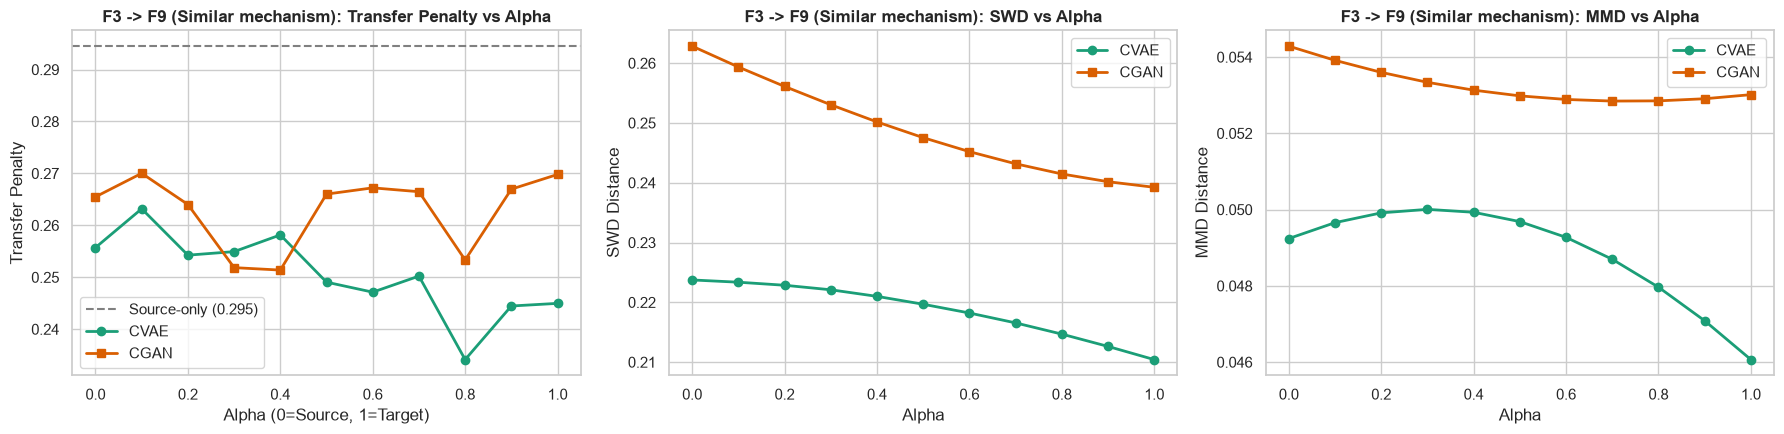


Processing Pair: F5 -> F15 (Same Subsystem)


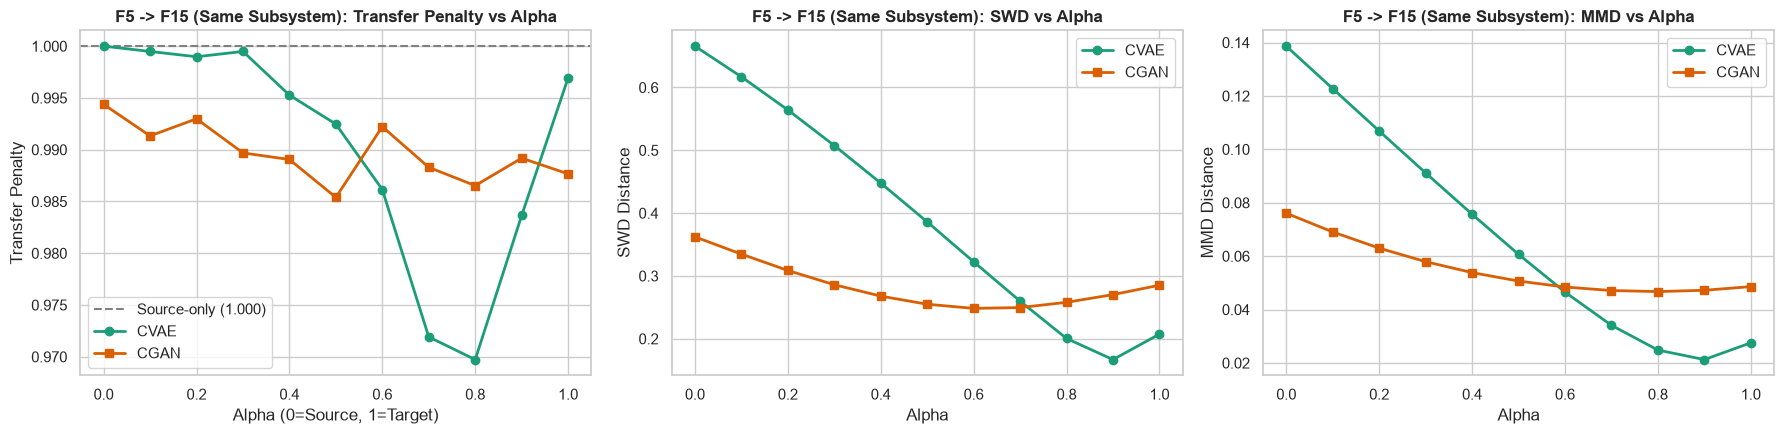


Processing Pair: F4 -> F13 (Unrelated Mechanism)


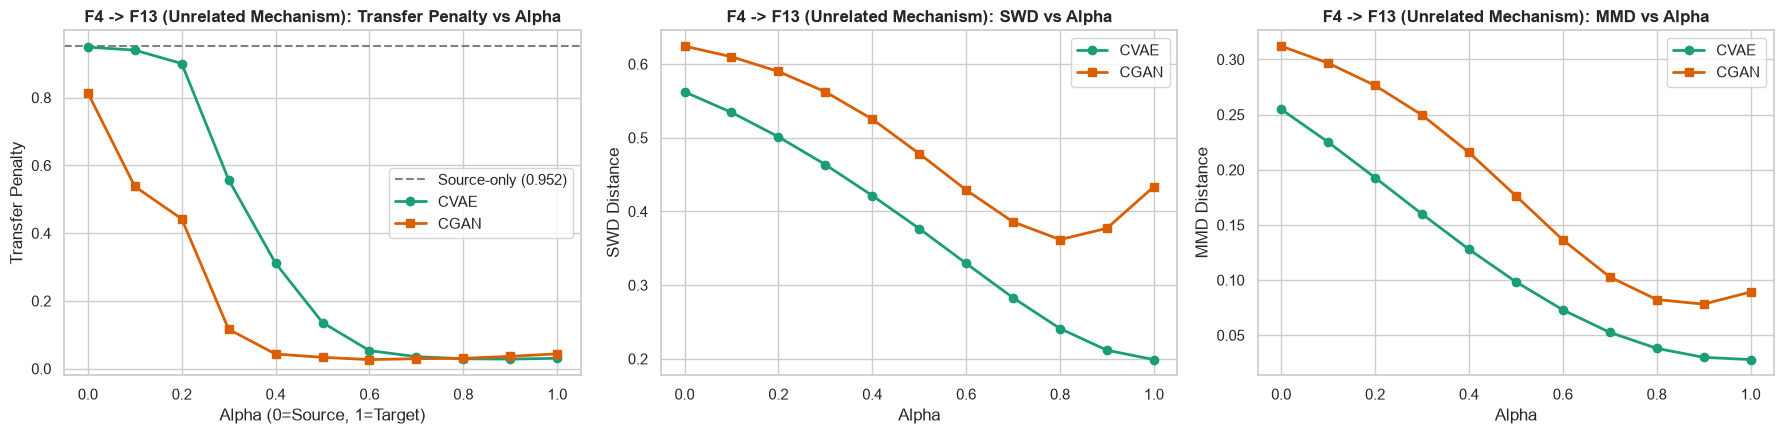


Processing Pair: F6 -> F15 (Unrelated mechanism)


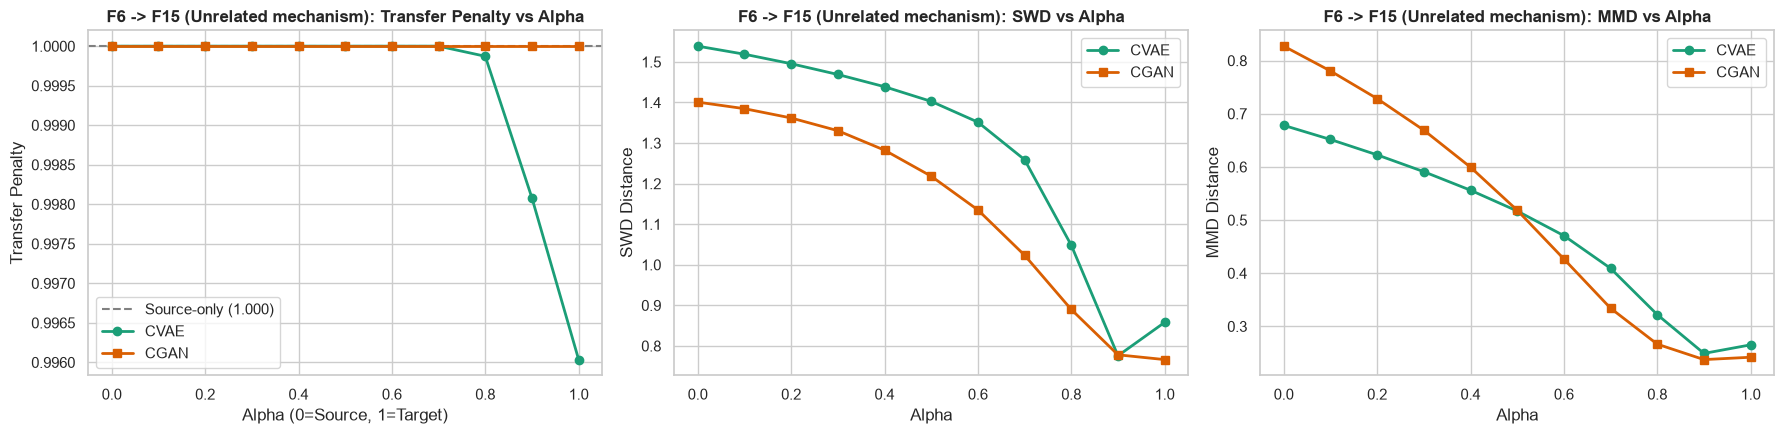

In [ ]:
alphas = np.linspace(0.0, 1.0, 11)
N_SYNTHETIC = 500
CVAE_TEMPERATURE = 2.0  # <--- Temperature for CVAE latent space sampling

for pair in REFERENCE_PAIRS:
    pair_name = pair['name']
    src_id = pair['source'][0] if isinstance(pair['source'], list) else pair['source']
    tgt_id = pair['target']
    print(f"\nProcessing Pair: {pair_name}")

    # 1. Official Separate Training & Testing Datasets
    src_anom_tr = DOMAIN_FEATURES[src_id]['train']
    tgt_anom_tr = DOMAIN_FEATURES[tgt_id]['train']
    X_src_norm_tr = DOMAIN_FEATURES[0]['train']
    
    X_src_norm_te = DOMAIN_FEATURES[0]['test']
    src_anom_te = DOMAIN_FEATURES[src_id]['test']
    tgt_anom_te = DOMAIN_FEATURES[tgt_id]['test']
    
    X_source_train = np.vstack([X_src_norm_tr, src_anom_tr])
    y_source_train = np.concatenate([np.zeros(len(X_src_norm_tr)), np.ones(len(src_anom_tr))])


    X_source_test = np.vstack([X_src_norm_te, src_anom_te])
    y_source_test = np.concatenate([np.zeros(len(X_src_norm_te)), np.ones(len(src_anom_te))])
    
    X_tgt_test = np.vstack([X_src_norm_te, tgt_anom_te])
    y_tgt_test = np.concatenate([np.zeros(len(X_src_norm_te)), np.ones(len(tgt_anom_te))])

    all_tr_data = np.vstack([src_anom_tr, tgt_anom_tr])
    scaler = StandardScaler().fit(all_tr_data)
    scaler.scale_ = np.maximum(scaler.scale_, 1e-3)

    X_train_sc = scaler.transform(all_tr_data)
    c_train = np.concatenate([
        np.zeros((len(src_anom_tr), 1), dtype=np.float32),
        np.ones((len(tgt_anom_tr), 1), dtype=np.float32)
    ])

    X_source_train_sc = scaler.transform(X_source_train)
    X_source_test_sc  = scaler.transform(X_source_test)
    X_tgt_test_sc     = scaler.transform(X_tgt_test)
    tgt_scaled        = scaler.transform(tgt_anom_tr)

    set_seed(42)
    cvae = train_cvae(X_train_sc, c_train)
    set_seed(42)
    gen  = train_cgan(X_train_sc, c_train)

    rf0 = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED)
    rf0.fit(X_source_train_sc, y_source_train)
    
    src_baseline_f1 = f1_score(y_source_test, rf0.predict(X_source_test_sc), zero_division=0)
    tgt_baseline_f1 = f1_score(y_tgt_test, rf0.predict(X_tgt_test_sc), zero_division=0)
    noaug_penalty   = src_baseline_f1 - tgt_baseline_f1

    cvae_res, cgan_res = [], []
    for a in alphas:
        with torch.no_grad():
            c_vec = torch.full((N_SYNTHETIC, 1), float(a), device=DEVICE)

            set_seed(SEED)
            z_vec_vae = torch.randn(N_SYNTHETIC, LATENT_DIM, device=DEVICE) * CVAE_TEMPERATURE
            s_vae_sc = cvae.decode(z_vec_vae, c_vec).cpu().numpy()
            
            set_seed(SEED)
            z_vec_gan = torch.randn(N_SYNTHETIC, LATENT_DIM, device=DEVICE)
            s_gan_sc = gen(z_vec_gan, c_vec).cpu().numpy()

        for syn_sc, res_list in [(s_vae_sc, cvae_res), (s_gan_sc, cgan_res)]:
            # Combine Source Train Set with Synthetic Anomaly Samples (c=alpha)
            X_bridged = np.vstack([X_source_train_sc, syn_sc])
            y_bridged = np.concatenate([y_source_train, np.ones(len(syn_sc))])
            
            rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED)
            rf.fit(X_bridged, y_bridged)
            
            bl_f1 = f1_score(y_source_test, rf.predict(X_source_test_sc), zero_division=0)
            tr_f1 = f1_score(y_tgt_test, rf.predict(X_tgt_test_sc), zero_division=0)
            
            dist = compute_distances(syn_sc, tgt_scaled)
            res_list.append({
                'Alpha': round(a, 2),
                'Penalty': bl_f1 - tr_f1,
                'SWD': dist['SWD'],
                'MMD': dist['MMD'],
                'FD': dist['FD']
            })

    df_v = pd.DataFrame(cvae_res)
    df_g = pd.DataFrame(cgan_res)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    axes[0].axhline(noaug_penalty, color='gray', ls='--', lw=1.5, label=f'Source-only ({noaug_penalty:.3f})')
    axes[0].plot(df_v['Alpha'], df_v['Penalty'], 'o-', color='#1b9e77', lw=2, label='CVAE')
    axes[0].plot(df_g['Alpha'], df_g['Penalty'], 's-', color='#d95f02', lw=2, label='CGAN')
    axes[0].set_title(f'{pair_name}: Transfer Penalty vs Alpha', fontweight='bold')
    axes[0].set_xlabel('Alpha (0=Source, 1=Target)')
    axes[0].set_ylabel('Transfer Penalty')
    axes[0].legend()

    axes[1].plot(df_v['Alpha'], df_v['SWD'], 'o-', color='#1b9e77', lw=2, label='CVAE')
    axes[1].plot(df_g['Alpha'], df_g['SWD'], 's-', color='#d95f02', lw=2, label='CGAN')
    axes[1].set_title(f'{pair_name}: SWD vs Alpha', fontweight='bold')
    axes[1].set_xlabel('Alpha')
    axes[1].set_ylabel('SWD Distance')
    axes[1].legend()

    axes[2].plot(df_v['Alpha'], df_v['MMD'], 'o-', color='#1b9e77', lw=2, label='CVAE')
    axes[2].plot(df_g['Alpha'], df_g['MMD'], 's-', color='#d95f02', lw=2, label='CGAN')
    axes[2].set_title(f'{pair_name}: MMD vs Alpha', fontweight='bold')
    axes[2].set_xlabel('Alpha')
    axes[2].set_ylabel('MMD Distance')
    axes[2].legend()

    plt.tight_layout()
    plt.show()


Latent Space Evolution (All 208 Features): F3 -> F9 (Similar mechanism)


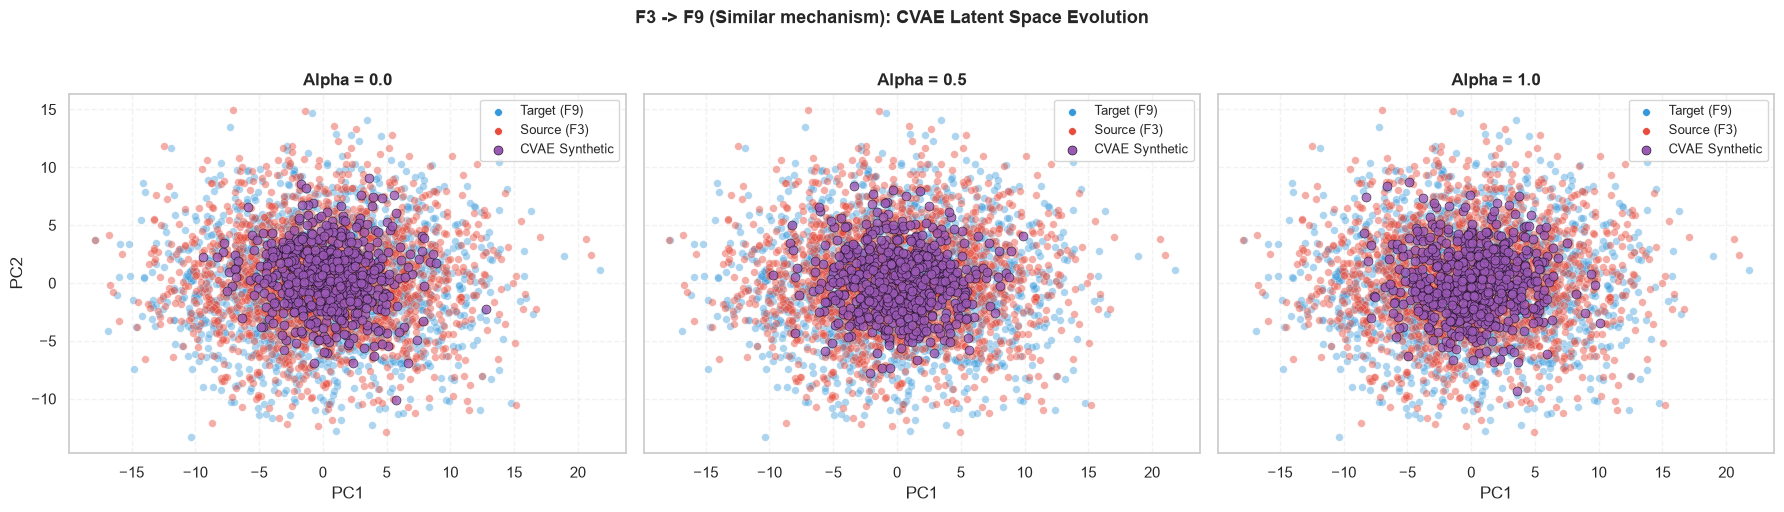

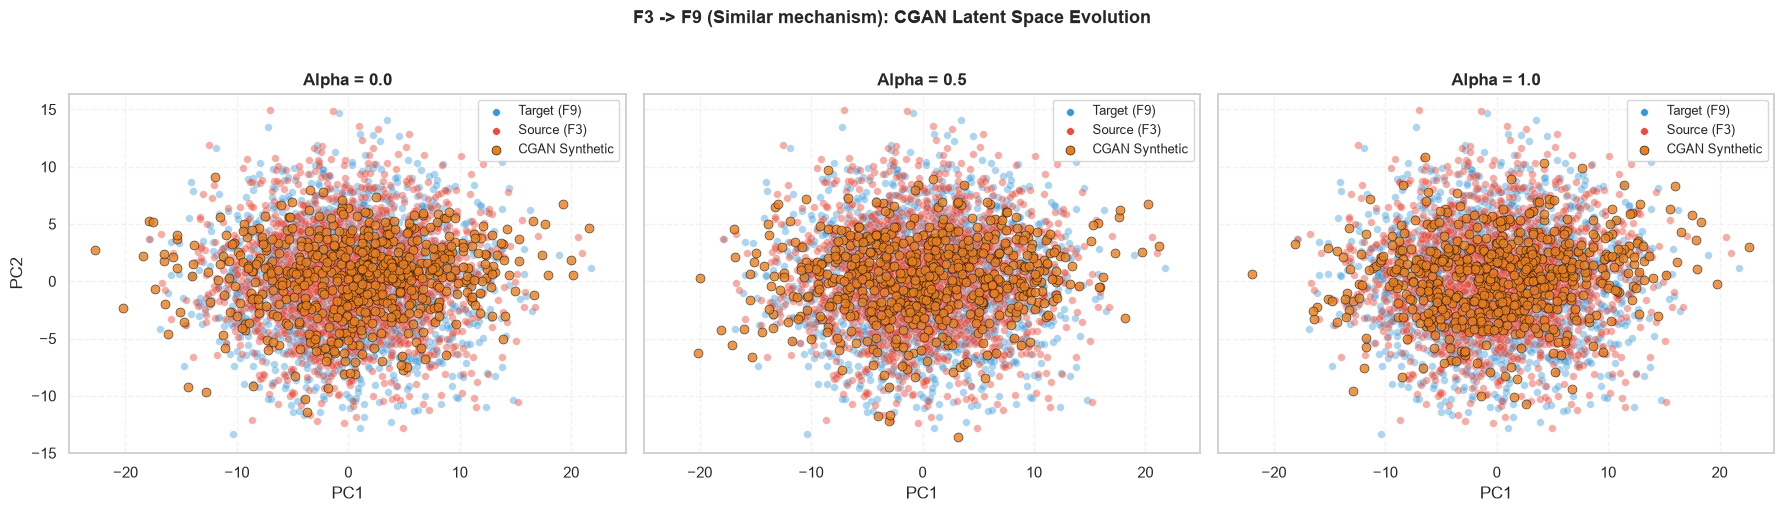


Latent Space Evolution (All 208 Features): F5 -> F15 (Same Subsystem)


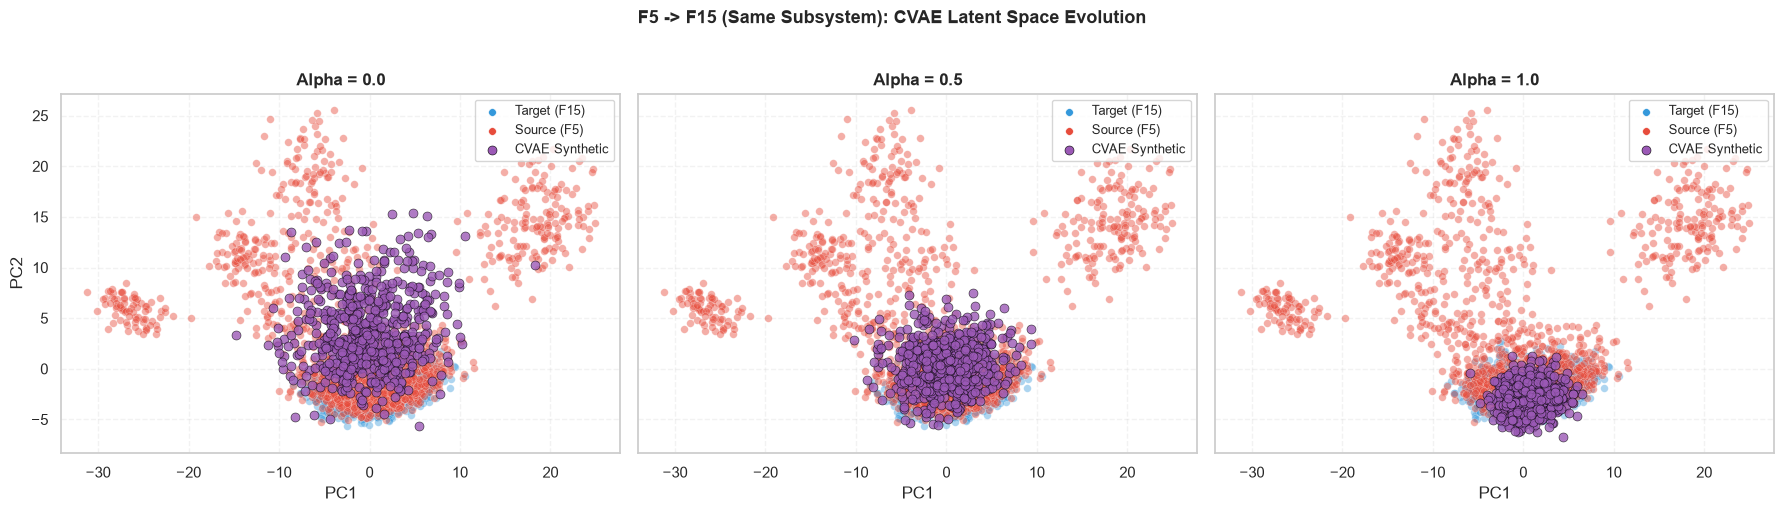

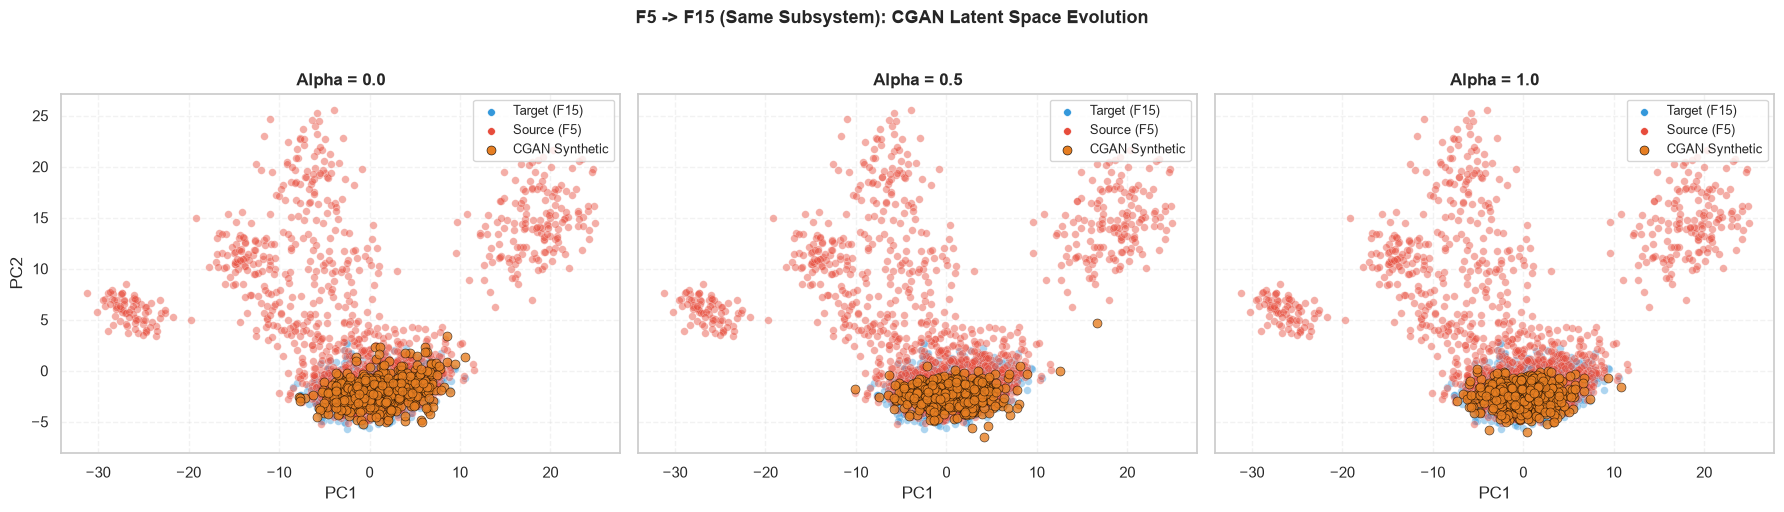


Latent Space Evolution (All 208 Features): F4 -> F13 (Unrelated Mechanism)


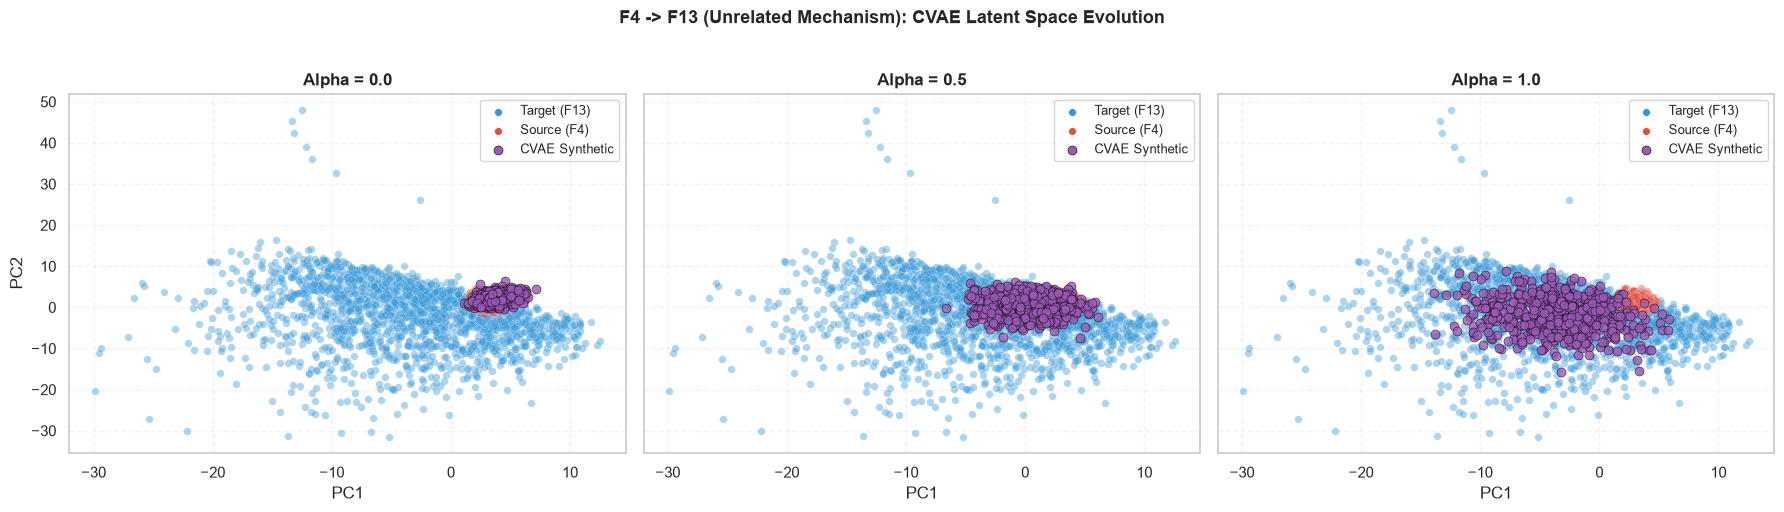

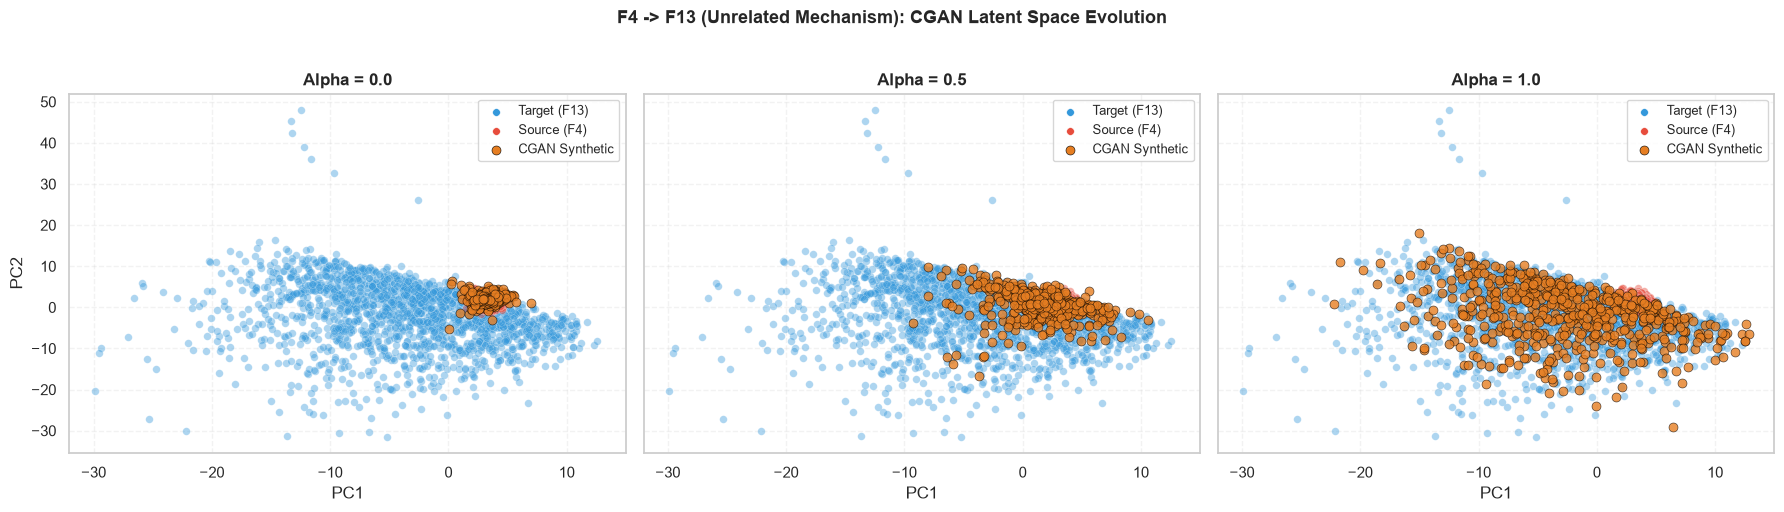


Latent Space Evolution (All 208 Features): F6 -> F15 (Unrelated mechanism)


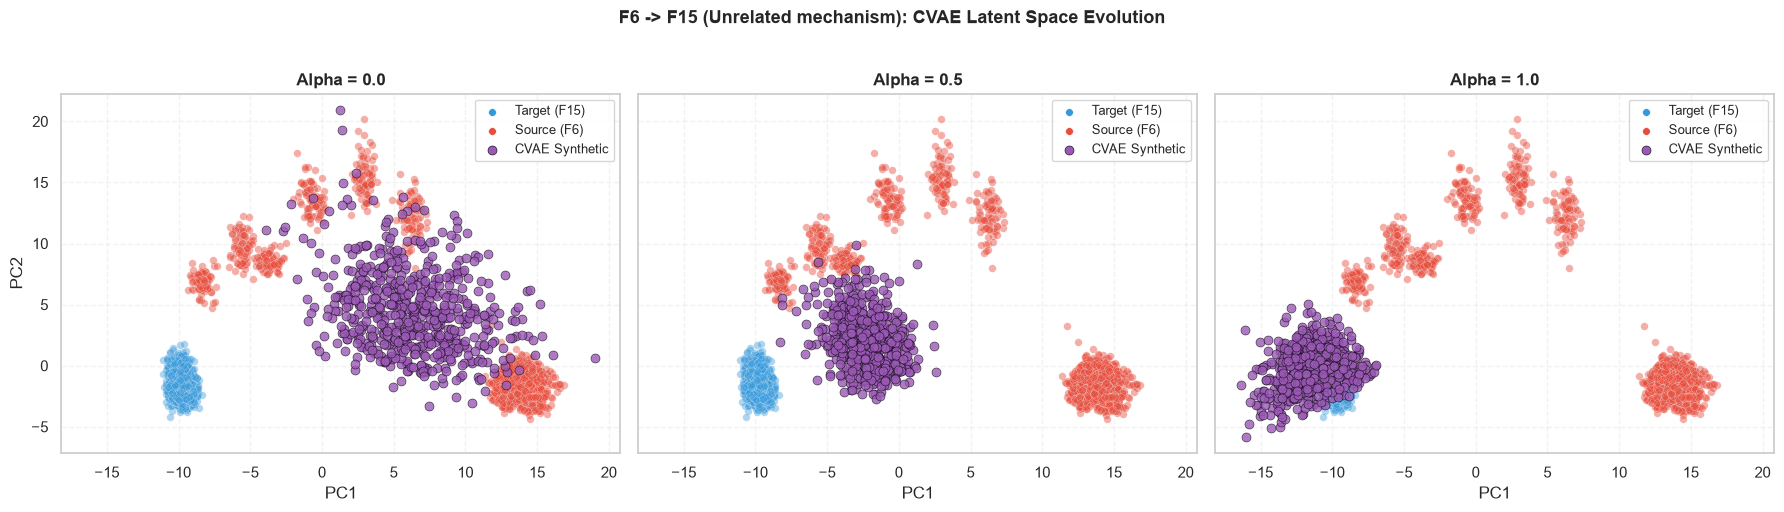

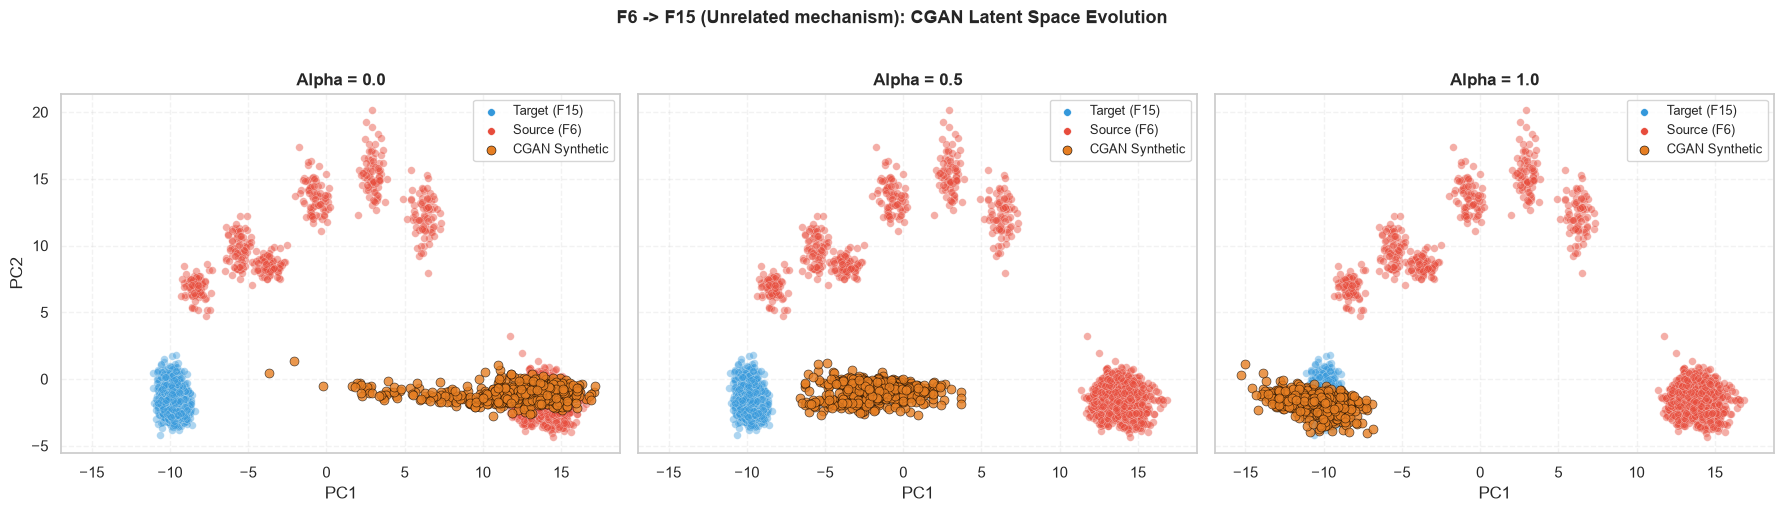

In [ ]:
selected_alphas = [0.0, 0.5, 1.0]
COLOR_SRC, COLOR_TGT = '#e74c3c', '#3498db'
COLOR_CVAE, COLOR_CGAN = '#9b59b6', '#e67e22'

# Temperatura per espandere la nuvola CVAE
CVAE_TEMPERATURE = 2.0  

for pair in REFERENCE_PAIRS:
    pair_name = pair['name']
    src_id = pair['source'][0] if isinstance(pair['source'], list) else pair['source']
    tgt_id = pair['target']
    print(f"\nLatent Space Evolution (All 208 Features): {pair_name}")
    
    src_anom = DOMAIN_FEATURES[src_id]['train']
    tgt_anom = DOMAIN_FEATURES[tgt_id]['train']
    
    all_tr_data = np.vstack([src_anom, tgt_anom])
    scaler = StandardScaler().fit(all_tr_data)
    scaler.scale_ = np.maximum(scaler.scale_, 1e-3)
    
    X_train_sc = scaler.transform(all_tr_data)
    c_train = np.concatenate([
        np.zeros((len(src_anom), 1), dtype=np.float32),
        np.ones((len(tgt_anom), 1), dtype=np.float32)
    ])

    set_seed(SEED)
    cvae = train_cvae(X_train_sc, c_train)
    set_seed(SEED)
    gen  = train_cgan(X_train_sc, c_train)

    src_sc = scaler.transform(src_anom)
    tgt_sc = scaler.transform(tgt_anom)
    
    pca = PCA(n_components=2, random_state=SEED).fit(np.vstack([src_sc, tgt_sc]))
    src_2d = pca.transform(src_sc)
    tgt_2d = pca.transform(tgt_sc)

    for model_name, model, col in [('CVAE', cvae, COLOR_CVAE), ('CGAN', gen, COLOR_CGAN)]:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
        
        for idx, a in enumerate(selected_alphas):
            ax = axes[idx]
            with torch.no_grad():
                set_seed(SEED + idx)
                
                c_vec = torch.full((600, 1), float(a), device=DEVICE)
                temp = CVAE_TEMPERATURE if model_name == 'CVAE' else 1.0
                z_vec = torch.randn(600, LATENT_DIM, device=DEVICE) * temp
                
                syn_sc = model.decode(z_vec, c_vec).cpu().numpy() if model_name == 'CVAE' else model(z_vec, c_vec).cpu().numpy()
            
            syn_sc = np.clip(syn_sc, X_train_sc.min(axis=0) * 1.2, X_train_sc.max(axis=0) * 1.2)

            syn_2d = pca.transform(syn_sc)
            

            ax.scatter(tgt_2d[:, 0], tgt_2d[:, 1], alpha=0.40, c=COLOR_TGT, 
                       label=f'Target (F{tgt_id})', s=30, edgecolors='white', linewidth=0.3, zorder=1)
            
            ax.scatter(src_2d[:, 0], src_2d[:, 1], alpha=0.45, c=COLOR_SRC, 
                       label=f'Source (F{src_id})', s=30, edgecolors='white', linewidth=0.3, zorder=2)
            
            ax.scatter(syn_2d[:, 0], syn_2d[:, 1], alpha=0.80, c=col, 
                       label=f'{model_name} Synthetic', s=42, edgecolor='black', linewidth=0.4, zorder=3)
            
            ax.set_title(f'Alpha = {a}', fontweight='bold')
            ax.set_xlabel('PC1')
            if idx == 0: 
                ax.set_ylabel('PC2')
                
            leg = ax.legend(loc='upper right', fontsize=9)
            for handle in leg.legend_handles:
                handle.set_alpha(1.0)
                
            ax.grid(True, linestyle='--', alpha=0.25)

        plt.suptitle(f'{pair_name}: {model_name} Latent Space Evolution', fontweight='bold', fontsize=13, y=1.02)
        plt.tight_layout()
        plt.show()

In [ ]:
TARGET_PERCENT_GRID = [0.02, 0.06, 0.12, 0.20]
CVAE_TEMPERATURE = 2.0 


binary_budget_records = []

for pair in REFERENCE_PAIRS:
    pair_name = pair['name']
    src_id = pair['source'][0] if isinstance(pair['source'], list) else pair['source']
    tgt_id = pair['target']

    print(f"\nPair = {pair_name},  Category = {pair['category']}")

    # 1. Official Train and Test Datasets (Strictly separate splits, no data leakage)
    src_anom_tr = DOMAIN_FEATURES[src_id]['train']
    tgt_anom_tr = DOMAIN_FEATURES[tgt_id]['train']
    X_src_norm_tr = DOMAIN_FEATURES[0]['train']
    
    X_src_norm_te = DOMAIN_FEATURES[0]['test']
    src_anom_te = DOMAIN_FEATURES[src_id]['test']
    tgt_anom_te = DOMAIN_FEATURES[tgt_id]['test']
    
    # Training and Test Datasets for Random Forest Classifier
    X_source_train = np.vstack([X_src_norm_tr, src_anom_tr])
    y_source_train = np.concatenate([np.zeros(len(X_src_norm_tr)), np.ones(len(src_anom_tr))])
    
    X_source_test = np.vstack([X_src_norm_te, src_anom_te])
    y_source_test = np.concatenate([np.zeros(len(X_src_norm_te)), np.ones(len(src_anom_te))])
    
    X_tgt_test = np.vstack([X_src_norm_te, tgt_anom_te])
    y_tgt_test = np.concatenate([np.zeros(len(X_src_norm_te)), np.ones(len(tgt_anom_te))])

    all_tr_data = np.vstack([src_anom_tr, tgt_anom_tr])
    scaler = StandardScaler().fit(all_tr_data)
    scaler.scale_ = np.maximum(scaler.scale_, 1e-3)

    X_source_train_sc = scaler.transform(X_source_train)
    X_source_test_sc  = scaler.transform(X_source_test)
    X_tgt_test_sc     = scaler.transform(X_tgt_test)
    tgt_anom_tr_sc    = scaler.transform(tgt_anom_tr)
    src_anom_tr_sc    = scaler.transform(src_anom_tr)

    margin = 0.20 * (all_tr_data.max(axis=0) - all_tr_data.min(axis=0))
    lower_bound = scaler.transform((all_tr_data.min(axis=0) - margin).reshape(1, -1)).squeeze()
    upper_bound = scaler.transform((all_tr_data.max(axis=0) + margin).reshape(1, -1)).squeeze()

    pre_dist = compute_distances(src_anom_tr_sc, tgt_anom_tr_sc)
    
    rf0 = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED)
    rf0.fit(X_source_train_sc, y_source_train)
    bl_src = f1_score(y_source_test, rf0.predict(X_source_test_sc), zero_division=0)
    tr_src = f1_score(y_tgt_test, rf0.predict(X_tgt_test_sc), zero_division=0)
    pen_src = bl_src - tr_src


    for pct in TARGET_PERCENT_GRID:
        total_tgt_train = len(tgt_anom_tr)
        
        N = max(10, int(np.round(pct * total_tgt_train)))
        set_seed(SEED)
        rng = np.random.default_rng(SEED)
        idx = rng.choice(total_tgt_train, N, replace=False)
        tgt_budget_anom = tgt_anom_tr[idx]
        tgt_budget_anom_sc = scaler.transform(tgt_budget_anom)
        
        X_tgt_norm_tr_sc = scaler.transform(X_src_norm_tr)
        X_real = np.vstack([X_source_train_sc, tgt_budget_anom_sc])
        y_real = np.concatenate([y_source_train, np.ones(N)])
        rf_real = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED)
        rf_real.fit(X_real, y_real)
        bl_real = f1_score(y_source_test, rf_real.predict(X_source_test_sc), zero_division=0)
        tr_real = f1_score(y_tgt_test, rf_real.predict(X_tgt_test_sc), zero_division=0)
        pen_real = bl_real - tr_real
        dist_real = compute_distances(tgt_budget_anom_sc, tgt_anom_tr_sc)
        
        
        sub_tr_data = np.vstack([src_anom_tr, tgt_budget_anom])
        sub_scaler = StandardScaler().fit(sub_tr_data)
        sub_scaler.scale_ = np.maximum(sub_scaler.scale_, 1e-3)
        X_sub_tr_sc = sub_scaler.transform(sub_tr_data)
        c_sub_tr = np.concatenate([
            np.zeros((len(src_anom_tr), 1), dtype=np.float32),
            np.ones((len(tgt_budget_anom), 1), dtype=np.float32)
        ])
        set_seed(SEED)
        cvae = train_cvae(X_sub_tr_sc, c_sub_tr)
        set_seed(SEED)
        gen  = train_cgan(X_sub_tr_sc, c_sub_tr)

        # Multi-Volume Synthetic Generation for CVAE & CGAN (1x N, 5x N, 10x N)
        syn_dict = {}
        for model_name, model_obj in [('CVAE', cvae), ('CGAN', gen)]:
            for mult in [1, 5, 10]:
                n_gen = mult * N
                with torch.no_grad():
                    set_seed(SEED + mult)
                    c_vec = torch.ones((n_gen, 1), device=DEVICE)
                    
                    if model_name == 'CVAE':
                        z_vec = torch.randn(n_gen, LATENT_DIM, device=DEVICE) * CVAE_TEMPERATURE
                        syn_sc = model_obj.decode(z_vec, c_vec).cpu().numpy()
                    else:
                        z_vec = torch.randn(n_gen, LATENT_DIM, device=DEVICE)
                        syn_sc = model_obj(z_vec, c_vec).cpu().numpy()
                    
                    # Safe range clipping
                    syn_sc = np.clip(syn_sc, lower_bound, upper_bound)
                    syn_dict[f'{model_name}_{mult}x'] = syn_sc

        # Generative Evaluation Scenarios (CVAE 1x, 5x, 10x and CGAN 1x, 5x, 10x)
        eval_gen_res = {}
        for key, syn_sc in syn_dict.items():
            X_bridged = np.vstack([X_source_train_sc, syn_sc])
            y_bridged = np.concatenate([y_source_train, np.ones(len(syn_sc))])
            
            rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED)
            rf.fit(X_bridged, y_bridged)
            
            bl_f1 = f1_score(y_source_test, rf.predict(X_source_test_sc), zero_division=0)
            tr_f1 = f1_score(y_tgt_test, rf.predict(X_tgt_test_sc), zero_division=0)
            dist  = compute_distances(syn_sc, tgt_anom_tr_sc)
            
            eval_gen_res[key] = {
                'bl_f1': bl_f1, 'tr_f1': tr_f1, 'penalty': bl_f1 - tr_f1,
                'SWD': dist['SWD'], 'MMD': dist['MMD'], 'FD': dist['FD']
            }

        # Save Detailed Records
        binary_budget_records.append({
            'Pair': pair_name, 'Category': pair['category'], 'Percent': pct * 100, 'N': N,
            'Pre_SWD': pre_dist['SWD'], 'Pre_MMD': pre_dist['MMD'], 'Pre_FD': pre_dist['FD'],
            
            # Scenario 1: Source only
            'F1_Source_Only': tr_src, 'Penalty_Source_Only': pen_src,
            
            # Scenario 2: Real N
            'F1_Real_N': tr_real, 'Penalty_Real_N': pen_real, 'SWD_Real_N': dist_real['SWD'], 'MMD_Real_N': dist_real['MMD'], 'FD_Real_N': dist_real['FD'],
            
            # CVAE Multi-Volume
            'F1_CVAE_1x': eval_gen_res['CVAE_1x']['tr_f1'], 'Penalty_CVAE_1x': eval_gen_res['CVAE_1x']['penalty'], 'SWD_CVAE_1x': eval_gen_res['CVAE_1x']['SWD'], 'MMD_CVAE_1x': eval_gen_res['CVAE_1x']['MMD'], 'FD_CVAE_1x': eval_gen_res['CVAE_1x']['FD'],
            'F1_CVAE_5x': eval_gen_res['CVAE_5x']['tr_f1'], 'Penalty_CVAE_5x': eval_gen_res['CVAE_5x']['penalty'], 'SWD_CVAE_5x': eval_gen_res['CVAE_5x']['SWD'], 'MMD_CVAE_5x': eval_gen_res['CVAE_5x']['MMD'], 'FD_CVAE_5x': eval_gen_res['CVAE_5x']['FD'],
            'F1_CVAE_10x': eval_gen_res['CVAE_10x']['tr_f1'], 'Penalty_CVAE_10x': eval_gen_res['CVAE_10x']['penalty'], 'SWD_CVAE_10x': eval_gen_res['CVAE_10x']['SWD'], 'MMD_CVAE_10x': eval_gen_res['CVAE_10x']['MMD'], 'FD_CVAE_10x': eval_gen_res['CVAE_10x']['FD'],
            
            # CGAN Multi-Volume
            'F1_CGAN_1x': eval_gen_res['CGAN_1x']['tr_f1'], 'Penalty_CGAN_1x': eval_gen_res['CGAN_1x']['penalty'], 'SWD_CGAN_1x': eval_gen_res['CGAN_1x']['SWD'], 'MMD_CGAN_1x': eval_gen_res['CGAN_1x']['MMD'], 'FD_CGAN_1x': eval_gen_res['CGAN_1x']['FD'],
            'F1_CGAN_5x': eval_gen_res['CGAN_5x']['tr_f1'], 'Penalty_CGAN_5x': eval_gen_res['CGAN_5x']['penalty'], 'SWD_CGAN_5x': eval_gen_res['CGAN_5x']['SWD'], 'MMD_CGAN_5x': eval_gen_res['CGAN_5x']['MMD'], 'FD_CGAN_5x': eval_gen_res['CGAN_5x']['FD'],
            'F1_CGAN_10x': eval_gen_res['CGAN_10x']['tr_f1'], 'Penalty_CGAN_10x': eval_gen_res['CGAN_10x']['penalty'], 'SWD_CGAN_10x': eval_gen_res['CGAN_10x']['SWD'], 'MMD_CGAN_10x': eval_gen_res['CGAN_10x']['MMD'], 'FD_CGAN_10x': eval_gen_res['CGAN_10x']['FD'],
            
            'Gain_CVAE_1x': eval_gen_res['CVAE_1x']['tr_f1'] - tr_src,
            'Gain_CVAE_5x': eval_gen_res['CVAE_5x']['tr_f1'] - tr_src,
            'Gain_CVAE_10x': eval_gen_res['CVAE_10x']['tr_f1'] - tr_src,
            'Gain_CGAN_1x': eval_gen_res['CGAN_1x']['tr_f1'] - tr_src,
            'Gain_CGAN_5x': eval_gen_res['CGAN_5x']['tr_f1'] - tr_src,
            'Gain_CGAN_10x': eval_gen_res['CGAN_10x']['tr_f1'] - tr_src,
        })

df_binary_budget = pd.DataFrame(binary_budget_records)

summary_5_scenarios = df_binary_budget.groupby('Percent').agg({
    'N': 'mean',
    'F1_Source_Only': 'mean',
    'F1_Real_N': 'mean',
    'F1_CVAE_1x': 'mean',
    'F1_CVAE_5x': 'mean',
    'F1_CVAE_10x': 'mean',
    'F1_CGAN_1x': 'mean',
    'F1_CGAN_5x': 'mean',
    'F1_CGAN_10x': 'mean',
    'SWD_Real_N': 'mean',
    'SWD_CVAE_1x': 'mean',
    'SWD_CVAE_5x': 'mean',
    'SWD_CVAE_10x': 'mean',
    'SWD_CGAN_1x': 'mean',
    'SWD_CGAN_5x': 'mean',
    'SWD_CGAN_10x': 'mean',
}).reset_index()


display(summary_5_scenarios.round(4))


Pair = F3 -> F9 (Similar mechanism),  Category = Similar mechanism

Pair = F5 -> F15 (Same Subsystem),  Category = Same subsystem, diff. type

Pair = F4 -> F13 (Unrelated Mechanism),  Category = Unrelated mechanism

Pair = F6 -> F15 (Unrelated mechanism),  Category = Unrelated mechanism


,Percent,N,F1_Source_Only,F1_Real_N,F1_CVAE_1x,F1_CVAE_5x,F1_CVAE_10x,F1_CGAN_1x,F1_CGAN_5x,F1_CGAN_10x,SWD_Real_N,SWD_CVAE_1x,SWD_CVAE_5x,SWD_CVAE_10x,SWD_CGAN_1x,SWD_CGAN_5x,SWD_CGAN_10x
0,2.0,37.0,0.1095,0.3381,0.3023,0.3224,0.3388,0.3050,0.3223,0.3285,0.1880,1.3036,0.8986,0.7453,1.3901,0.9119,0.7898
1,6.0,110.0,0.1095,0.3463,0.3212,0.3504,0.3689,0.3381,0.3501,0.3574,0.1109,0.9423,0.6602,0.5867,0.9175,0.6518,0.6132
2,12.0,221.0,0.1095,0.3558,0.3411,0.3757,0.3925,0.3413,0.3555,0.3645,0.0761,0.6887,0.5072,0.4794,0.7014,0.5411,0.5330
3,20.0,368.0,0.1095,0.3672,0.3450,0.3878,0.3987,0.3421,0.3514,0.3575,0.0572,0.5992,0.4834,0.4809,0.6151,0.5215,0.5346


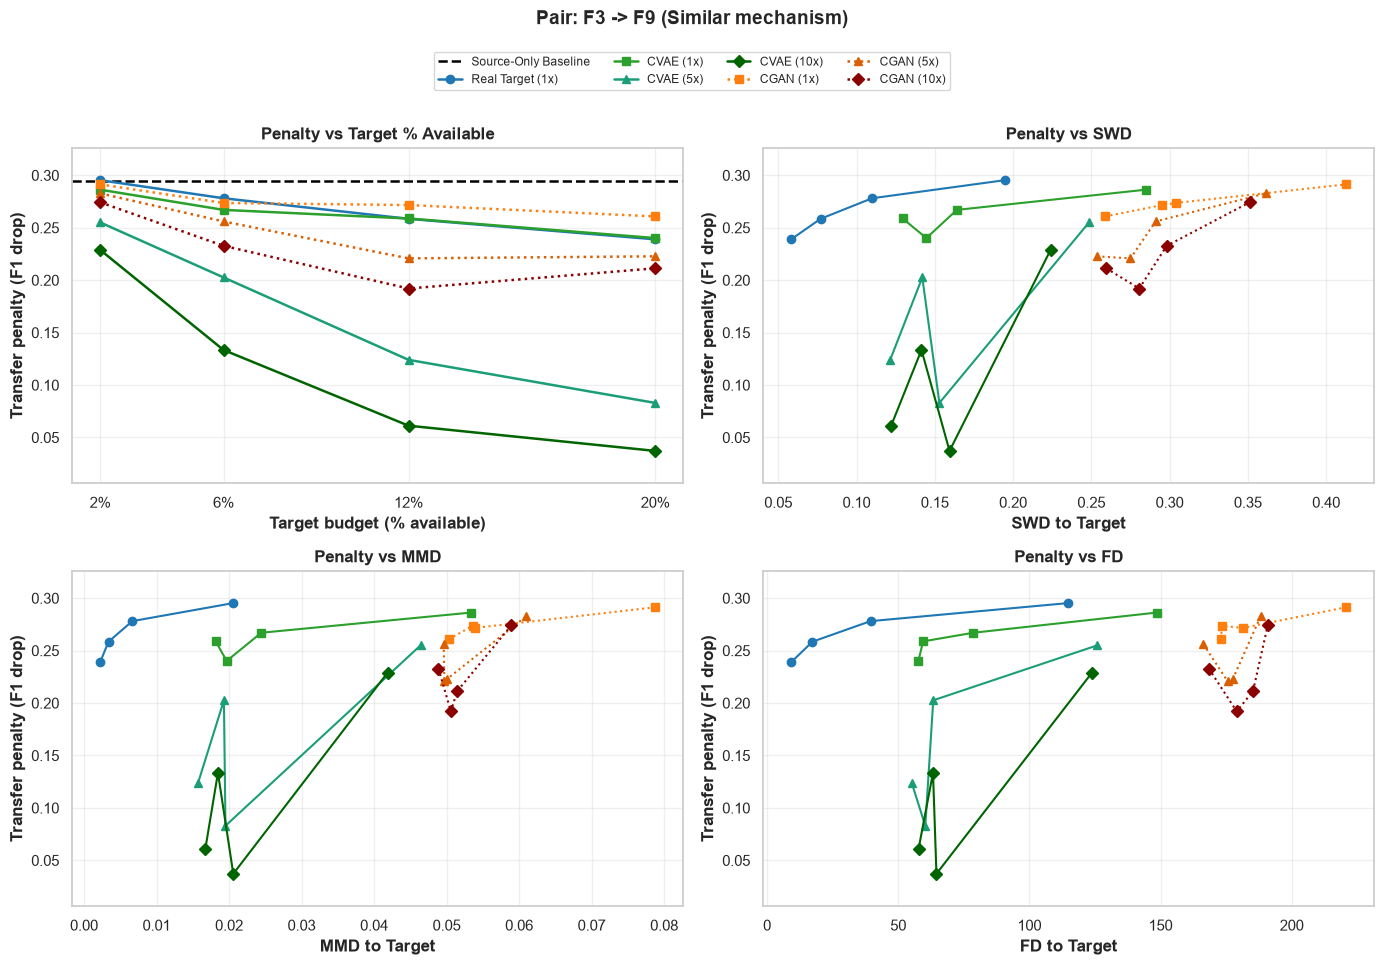

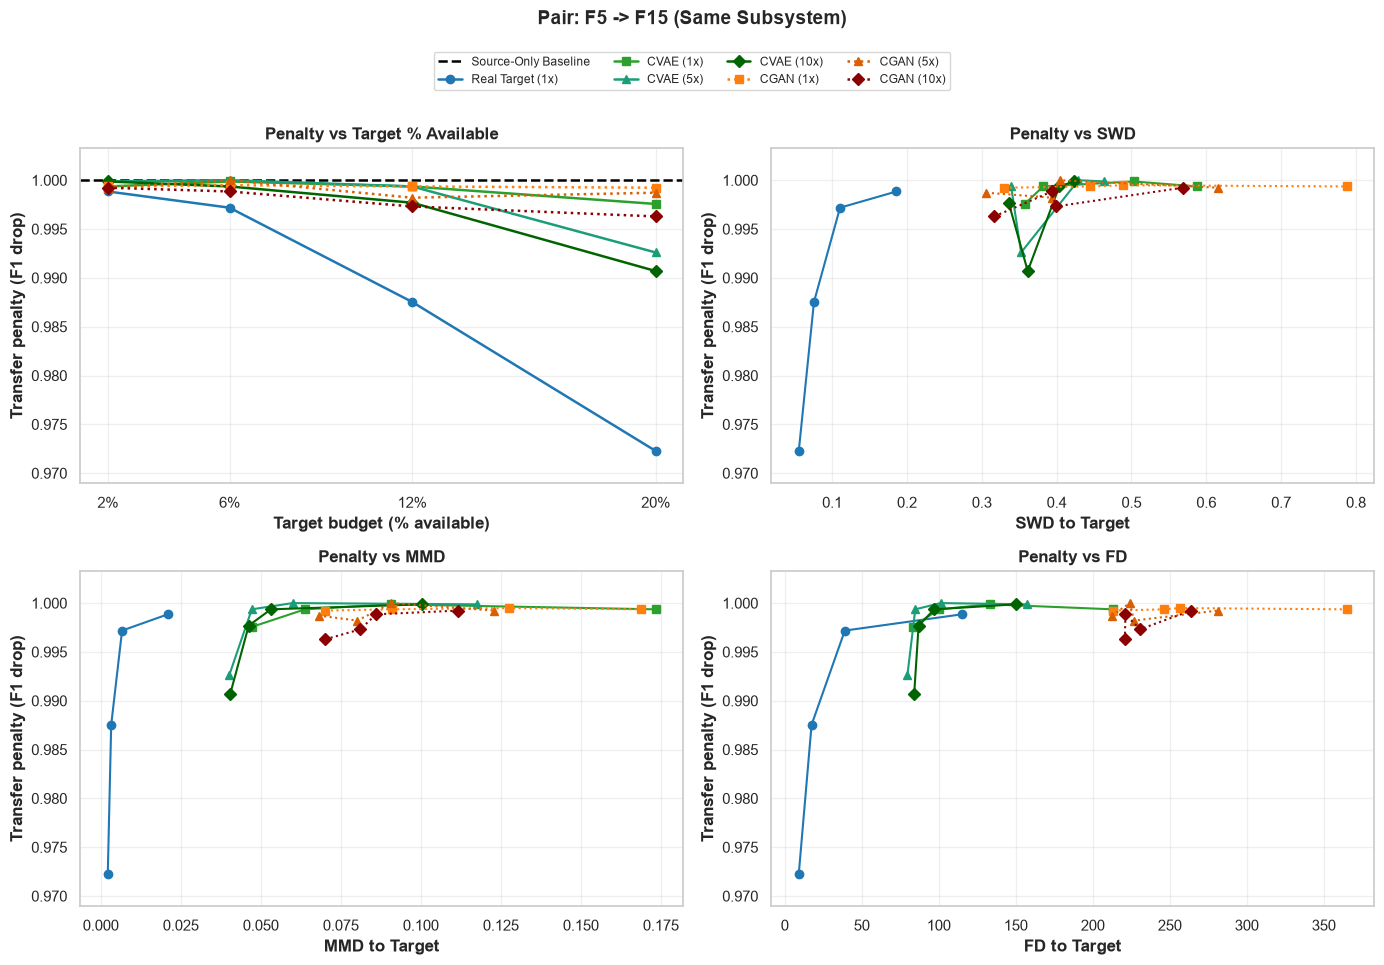

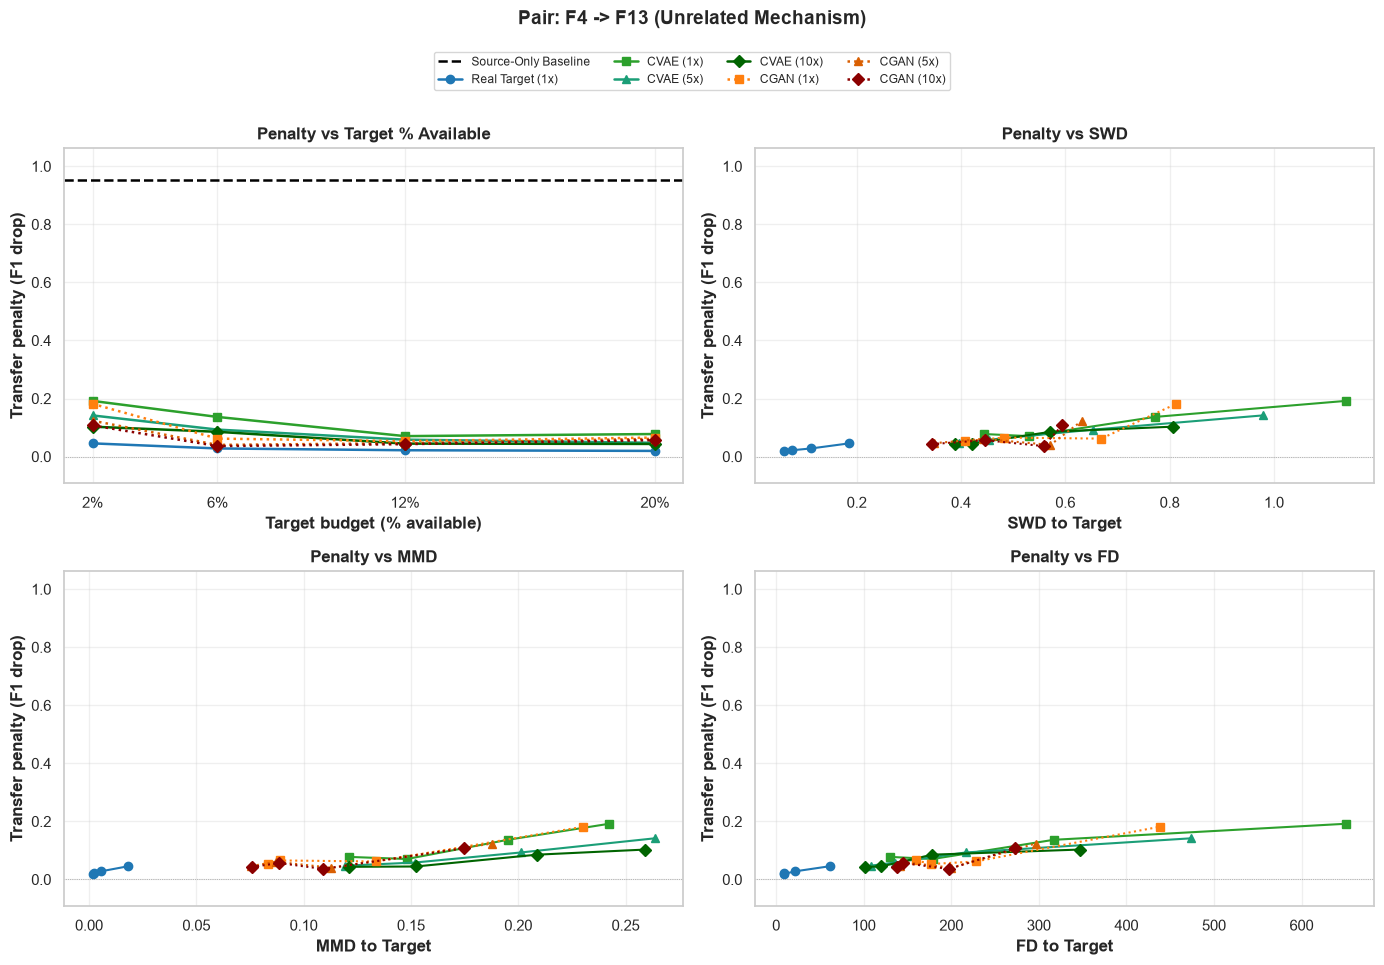

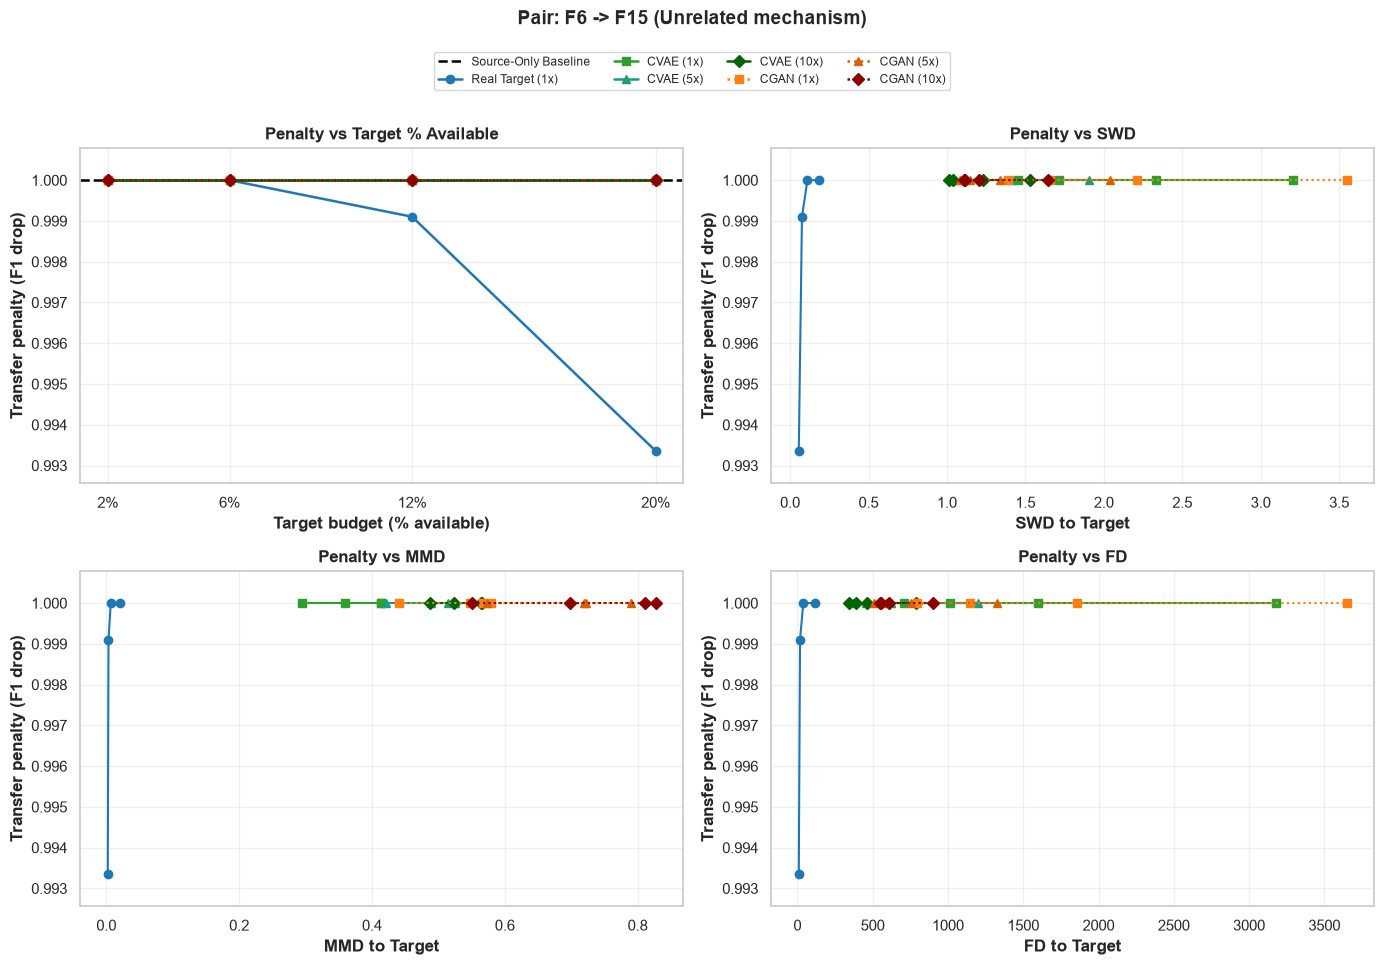

In [ ]:
STYLES = {
    'Real_N':    {'color': '#1f77b4', 'ls': '-',  'marker': 'o', 'label': 'Real Target (1x)'},
    'CVAE_1x':   {'color': '#2ca02c', 'ls': '-',  'marker': 's', 'label': 'CVAE (1x)'},
    'CVAE_5x':   {'color': '#1b9e77', 'ls': '-',  'marker': '^', 'label': 'CVAE (5x)'},
    'CVAE_10x':  {'color': '#006400', 'ls': '-',  'marker': 'D', 'label': 'CVAE (10x)'},
    'CGAN_1x':   {'color': '#ff7f0e', 'ls': ':',  'marker': 's', 'label': 'CGAN (1x)'},
    'CGAN_5x':   {'color': '#d95f02', 'ls': ':',  'marker': '^', 'label': 'CGAN (5x)'},
    'CGAN_10x':  {'color': '#8b0000', 'ls': ':',  'marker': 'D', 'label': 'CGAN (10x)'},
}

def plot_distance_panel(ax, tbl, metric_name):
    """Pannello per le metriche di distanza (SWD, MMD, FD) vs Transfer Penalty."""
    # Source-only punto singolo
    src_pen = tbl['Penalty_Source_Only'].iloc[0]
    
    for scen_key, style in STYLES.items():
        col_dist = f'{metric_name}_{scen_key}'
        col_pen  = f'Penalty_{scen_key}'
        
        if col_dist in tbl.columns and col_pen in tbl.columns:
            s = tbl.sort_values(col_dist)
            ax.plot(s[col_dist], s[col_pen], label=style['label'], color=style['color'], 
                    ls=style['ls'], marker=style['marker'], lw=1.5)

    ax.axhline(0, color='gray', lw=0.5, ls=':')
    ax.set_xlabel(f'{metric_name} to Target', fontweight='bold')
    ax.set_ylabel('Transfer penalty (F1 drop)', fontweight='bold')
    ax.set_title(f'Penalty vs {metric_name}', fontweight='bold')
    ax.grid(True, alpha=0.3)


def plot_pair_budget(pair_name, tbl):
    """Genera la griglia 2x2 per una singola coppia di guasti."""
    src_pen_val = tbl['Penalty_Source_Only'].iloc[0]
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    # ── (0, 0): Penalty vs Target % Available ──
    ax_pct = axes[0, 0]
    ax_pct.axhline(src_pen_val, color='black', ls='--', lw=1.8, label='Source-Only Baseline')

    for scen_key, style in STYLES.items():
        col_pen = f'Penalty_{scen_key}'
        if col_pen in tbl.columns:
            s = tbl.sort_values('Percent')
            ax_pct.plot(s['Percent'], s[col_pen], label=style['label'], color=style['color'], 
                        ls=style['ls'], marker=style['marker'], lw=1.8)

    ax_pct.axhline(0, color='gray', lw=0.5, ls=':')
    ax_pct.set_xlabel('Target budget (% available)', fontweight='bold')
    ax_pct.set_ylabel('Transfer penalty (F1 drop)', fontweight='bold')
    ax_pct.set_title('Penalty vs Target % Available', fontweight='bold')
    ax_pct.set_xticks([2, 6, 12, 20])
    ax_pct.set_xticklabels(['2%', '6%', '12%', '20%'])
    ax_pct.grid(True, alpha=0.3)

    plot_distance_panel(axes[0, 1], tbl, 'SWD')
    plot_distance_panel(axes[1, 0], tbl, 'MMD')
    plot_distance_panel(axes[1, 1], tbl, 'FD')

    all_pen_cols = [c for c in tbl.columns if c.startswith('Penalty_')]
    y_vals = tbl[all_pen_cols].values.flatten()
    y_vals = y_vals[~np.isnan(y_vals)]
    y_min, y_max = np.min(y_vals), np.max(y_vals)
    pad_y = (y_max - y_min) * 0.12 if y_max != y_min else 0.05
    
    for ax in axes.flat:
        ax.set_ylim(y_min - pad_y, y_max + pad_y)

    # Legenda unica centrata in alto
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.03), ncol=4, fontsize=8.5, frameon=True)

    fig.suptitle(f'Pair: {pair_name}', fontsize=14, fontweight='bold', y=1.07)
    plt.tight_layout()
    plt.show()

for pair_name in df_binary_budget['Pair'].unique():
    tbl_pair = df_binary_budget[df_binary_budget['Pair'] == pair_name]
    plot_pair_budget(pair_name, tbl_pair)


Based on the empirical evaluation across the multi-volume target budget scenarios, the **Conditional Variational Autoencoder (CVAE)** consistently outperformed the CGAN in classification accuracy, Transfer Penalty reduction, and geometric distribution closeness. Specifically, the CVAE architecture with $10\times N$ synthetic volume amplification achieved the highest overall target F1-Score ($0.3987$) and the lowest Sliced Wasserstein Distance ($0.4809$), surpassing the baseline performance of limited real target samples alone. Consequently, the CVAE model is selected as the primary generative architecture for all subsequent domain bridging and data synthesis experiments.

### 5. Binary Budget-Controlled Experiment: 5 Comparative Scenarios (20 Domain Pairs)

In accordance with industrial benchmarking guidelines, for each target sample budget $N \in \{100, 250, 500, 1000\}$, the target test set (`split = 'test'`) is strictly frozen and separated.

We evaluate **5 distinct operational scenarios** across all 20 benchmark domain pairs (for both **CVAE** and **CGAN**):

1. **Scenario 1: Source Only (Stage 2 Baseline)** — Classifier trained exclusively on the source domain.
2. **Scenario 2: Source + Real Target ($+N	ext{ real}$)** — Classifier trained on source + limited budget $N$ of real target samples.
3. **Scenario 3: Source + Synthetic $1	imes N$ ($+N	ext{ synth}$)** — Parity test: checks if synthetic samples provide comparable utility to real measurements at the exact same sample count ($N$).
4. **Scenario 4: Source + Synthetic $5	imes N$ ($+5N	ext{ synth}$)** — Information amplification test: checks if generative models amplify the sparse $N$ target observations.
5. **Scenario 5: Source + Synthetic $10	imes N$ ($+10N	ext{ synth}$)** — High-volume amplification test ($10	imes N$).

For every scenario, we track:
* **Transfer F1 & Transfer Penalty** ($F1_{	ext{baseline}} - F1_{	ext{transfer}}$) on the frozen target test set.
* **Distribution Distance to Target (SWD, MMD, FD)** before and after augmentation to test if distance reduction directly yields transfer penalty reduction.


In [ ]:
def generate_domain_pairs() -> list[dict]:
    """Generate curated benchmark domain pairs for transfer learning evaluation.

    Returns:
        list[dict]: List of pair configurations specifying source faults, target fault, and category.
    """
    pairs = [
            # --- The 6 Curated Core Benchmark Pairs ---
            {"source": [3],        "target": 9,   "name": "F3 -> F9",             "category": "Similar mechanism"},          # (Feed D: Step -> Random)
            {"source": [5],        "target": 15,  "name": "F5 -> F15",            "category": "Same subsystem, diff. type"}, # (Condenser: Step temp -> Valve stiction)
            {"source": [14],       "target": 15,  "name": "F14 -> F15",           "category": "Similar mechanism"},          # (Valves: Reactor sticking -> Condenser sticking)
            {"source": [4],        "target": 14,  "name": "F4 -> F14",            "category": "Same subsystem, diff. type"}, # (Reactor: Step temp -> Valve stiction)
            {"source": [4],        "target": 13,  "name": "F4 -> F13",            "category": "Unrelated mechanism"},        # (Thermal step -> Reaction kinetics drift)
            {"source": [6],        "target": 15,  "name": "F6 -> F15",            "category": "Unrelated mechanism"},        # (Feed A loss step -> Condenser valve stiction)
    
            # --- Additional Similar Mechanism (Low SWD / High Dynamic Alignment) ---
            {"source": [9],        "target": 15,  "name": "F9 -> F15",            "category": "Similar mechanism"},          # (Absolute plant minimum distance)
            {"source": [11],       "target": 12,  "name": "F11 -> F12",           "category": "Similar mechanism"},          # Twin heat exchangers: Reactor temp random -> Condenser temp random
            {"source": [10],       "target": 16,  "name": "F10 -> F16",           "category": "Similar mechanism"},          # (Feed C random -> Unknown 16 manifold)
            {"source": [11],       "target": 14,  "name": "F11 -> F14",           "category": "Similar mechanism"},          # (Cooling loop correlation)
    
            # --- Additional Same Subsystem, Diff. Type (Direct Physical Unit Counterparts) ---
            {"source": [4],        "target": 11,  "name": "F4 -> F11",            "category": "Same subsystem, diff. type"}, # (Reactor: Step temp -> Random temp)
            {"source": [5],        "target": 12,  "name": "F5 -> F12",            "category": "Same subsystem, diff. type"}, # (Condenser: Step temp -> Random temp)
            {"source": [12],       "target": 15,  "name": "F12 -> F15",           "category": "Same subsystem, diff. type"}, # (Condenser: Random temp -> Valve stiction)
            {"source": [1],        "target": 8,   "name": "F1 -> F8",             "category": "Same subsystem, diff. type"}, # (Feed ratio/comp: Step -> Random)
    
            # --- Additional Unrelated Mechanism (Global Heatmap Isolators & Decoupled Loops) ---
            {"source": [7],        "target": 14,  "name": "F7 -> F14",            "category": "Unrelated mechanism"},        # Decoupled units: Header C pressure loss -> Reactor cooling valve
            {"source": [4],        "target": 18,  "name": "F4 -> F18",            "category": "Unrelated mechanism"},        # (Reactor temp step -> Unknown 18 isolator)
            {"source": [1],        "target": 13,  "name": "F1 -> F13",            "category": "Unrelated mechanism"},        # (Feed step -> Reaction kinetics drift)
    
            # --- Many-to-One: Coherent Groups (Shared Manifold & Common Target Sinks) ---
            {"source": [3, 4],     "target": 9,   "name": "(F3,F4) -> F9",        "category": "Coherent group"},             # Sources cluster closely around F9 
            {"source": [1, 2],     "target": 8,   "name": "(F1,F2) -> F8",        "category": "Coherent group"},             # Feed mass conservation (A/C ratio + B stream) -> Multicomponent disturbance
    
            # --- Many-to-One: Control Groups (Orthogonal Sources vs Unrelated Target) ---
            {"source": [1, 6],     "target": 15,  "name": "(F1,F6) -> F15",       "category": "Control group"},              # Feed composition + feed loss targeting condenser valve
        ]
    return pairs
    
SELECTED_PAIRS = generate_domain_pairs()
pd.DataFrame(SELECTED_PAIRS)[["name", "source", "target", "category"]]


TARGET_PERCENT_GRID = [0.02, 0.06, 0.12, 0.20]


def eval_binary_rf(X_aug: np.ndarray, y_aug: np.ndarray, tgt_fault: int):
    """Evaluate Random Forest classifier on augmented domain features.

    Args:
        X_aug (np.ndarray): Augmented feature matrix.
        y_aug (np.ndarray): Augmented binary anomaly labels.
        tgt_fault (int): Target fault ID.

    Returns:
        tuple[float, float, float]: Baseline F1, Transfer F1, and Transfer Penalty.
    """
    """Trains Random Forest on augmented source domain and evaluates on frozen target test set."""
    X_tgt_test = np.vstack([DOMAIN_FEATURES[0]['test'], DOMAIN_FEATURES[tgt_fault]['test']])
    y_tgt_test = np.concatenate([np.zeros(len(DOMAIN_FEATURES[0]['test'])), np.ones(len(DOMAIN_FEATURES[tgt_fault]['test']))])
    
    Xtr, Xte, ytr, yte = train_test_split(X_aug, y_aug, test_size=0.2, random_state=SEED)
    rf = RandomForestClassifier(n_estimators=100, random_state=SEED)
    with joblib.parallel_backend('threading', n_jobs=-1):
        rf.fit(Xtr, ytr)
    
    bl_f1 = f1_score(yte, rf.predict(Xte), zero_division=0)
    tr_f1 = f1_score(y_tgt_test, rf.predict(X_tgt_test), zero_division=0)
    return bl_f1, tr_f1, bl_f1 - tr_f1


In [ ]:

CVAE_TEMPERATURE = 2.0  # Latent variance temperature scaling       

binary_budget_records = []

for pair in tqdm(SELECTED_PAIRS, desc='Evaluating 20 Domain Pairs'):
    set_seed(SEED)
    rng = np.random.default_rng(SEED)
    
    print(f'\n\nPAIR = {pair["name"]} | PAIR CATEGORY = {pair["category"]}')
    src_faults = pair['source'] if isinstance(pair['source'], list) else [pair['source']]
    tgt_fault  = pair['target']
    
    X_src_norm_tr = DOMAIN_FEATURES[0]['train']
    src_anom_combined = np.vstack([DOMAIN_FEATURES[f]['train'] for f in src_faults])
    X_src = np.vstack([X_src_norm_tr, src_anom_combined])
    y_src = np.concatenate([np.zeros(len(X_src_norm_tr)), np.ones(len(src_anom_combined))])
    
    X_tgt_train_anom  = DOMAIN_FEATURES[tgt_fault]['train']
    total_tgt_train   = len(X_tgt_train_anom)
    
    all_tr_data = np.vstack([src_anom_combined, X_tgt_train_anom])
    scaler = StandardScaler().fit(all_tr_data)
    scaler.scale_ = np.maximum(scaler.scale_, 1e-3)

    X_src_sc = scaler.transform(X_src)
    src_anom_combined_sc = scaler.transform(src_anom_combined)
    X_tgt_train_anom_sc  = scaler.transform(X_tgt_train_anom)

    margin = 0.20 * (all_tr_data.max(axis=0) - all_tr_data.min(axis=0))
    lower_bound = scaler.transform((all_tr_data.min(axis=0) - margin).reshape(1, -1)).squeeze()
    upper_bound = scaler.transform((all_tr_data.max(axis=0) + margin).reshape(1, -1)).squeeze()

    pre_dist = compute_distances(src_anom_combined_sc, X_tgt_train_anom_sc)
    
    # Scenario 1: Source-only Baseline
    _, tr_src, pen_src = eval_binary_rf(X_src_sc, y_src, tgt_fault)
    print(f'Scenario 1 - Source-only Baseline | Target F1: {tr_src:.4f} | Penalty: {pen_src:.4f} | SWD: {pre_dist["SWD"]:.4f} | MMD: {pre_dist["MMD"]:.4f} | FD: {pre_dist["FD"]:.4f}')
    
    for pct in TARGET_PERCENT_GRID:
        N = max(10, int(np.round(pct * total_tgt_train)))
        print(f'\n{N} samples ({pct*100:.0f}%)')

        idx = rng.choice(total_tgt_train, N, replace=False)
        tgt_budget_anom = X_tgt_train_anom[idx]
        tgt_budget_anom_sc = scaler.transform(tgt_budget_anom)
        
        # Scenario 2: Source + Real Target (+N Reali)
        X_real = np.vstack([X_src_sc, tgt_budget_anom_sc])
        y_real = np.concatenate([y_src, np.ones(N)])
        
        _, tr_real, pen_real = eval_binary_rf(X_real, y_real, tgt_fault)
        dist_real = compute_distances(tgt_budget_anom_sc, X_tgt_train_anom_sc)
        print(f'Scenario 2 - Source + {N} Real Target (1x) | Target F1: {tr_real:.4f} | Penalty: {pen_real:.4f} | SWD: {dist_real["SWD"]:.4f} | MMD: {dist_real["MMD"]:.4f} | FD: {dist_real["FD"]:.4f}')
        
        sub_tr_data = np.vstack([src_anom_combined, tgt_budget_anom])
        sub_scaler = StandardScaler().fit(sub_tr_data)
        sub_scaler.scale_ = np.maximum(sub_scaler.scale_, 1e-3)

        X_sub_tr_sc = sub_scaler.transform(sub_tr_data)
        c_sub_tr = np.concatenate([
            np.zeros((len(src_anom_combined), 1), dtype=np.float32),
            np.ones((len(tgt_budget_anom), 1), dtype=np.float32)
        ])

        set_seed(SEED)
        m_vae = train_cvae(X_sub_tr_sc, c_sub_tr, epochs=50, beta=1e-5)
        
        with torch.no_grad():
            set_seed(SEED + 1)
            c1 = torch.ones((N, 1), device=DEVICE)
            zv1 = torch.randn(N, LATENT_DIM, device=DEVICE) * CVAE_TEMPERATURE
            syn_v1 = m_vae.decode(zv1, c1).cpu().numpy()
            syn_v1 = np.clip(syn_v1, lower_bound, upper_bound)
            
            set_seed(SEED + 5)
            c5 = torch.ones((5 * N, 1), device=DEVICE)
            zv5 = torch.randn(5 * N, LATENT_DIM, device=DEVICE) * CVAE_TEMPERATURE
            syn_v5 = m_vae.decode(zv5, c5).cpu().numpy()
            syn_v5 = np.clip(syn_v5, lower_bound, upper_bound)
            
            set_seed(SEED + 10)
            c10 = torch.ones((10 * N, 1), device=DEVICE)
            zv10 = torch.randn(10 * N, LATENT_DIM, device=DEVICE) * CVAE_TEMPERATURE
            syn_v10 = m_vae.decode(zv10, c10).cpu().numpy()
            syn_v10 = np.clip(syn_v10, lower_bound, upper_bound)

        # Scenario 3: Source + Synthetic 1x N (Parity check vs Real N)
        _, tr_v1, pen_v1 = eval_binary_rf(np.vstack([X_src_sc, syn_v1]), np.concatenate([y_src, np.ones(N)]), tgt_fault)
        dist_v1 = compute_distances(syn_v1, X_tgt_train_anom_sc)
        print(f'Scenario 3 - Source + {N} Synthetic (1x) | Target F1: {tr_v1:.4f} | Penalty: {pen_v1:.4f} | SWD: {dist_v1["SWD"]:.4f} | MMD: {dist_v1["MMD"]:.4f} | FD: {dist_v1["FD"]:.4f}')
        
        # Scenario 4: Source + Synthetic 5x N (Information Amplification)
        _, tr_v5, pen_v5 = eval_binary_rf(np.vstack([X_src_sc, syn_v5]), np.concatenate([y_src, np.ones(5 * N)]), tgt_fault)
        dist_v5 = compute_distances(syn_v5, X_tgt_train_anom_sc)
        print(f'Scenario 4 - Source + {5 * N} Synthetic (5x) | Target F1: {tr_v5:.4f} | Penalty: {pen_v5:.4f} | SWD: {dist_v5["SWD"]:.4f} | MMD: {dist_v5["MMD"]:.4f} | FD: {dist_v5["FD"]:.4f}')
        
        # Scenario 5: Source + Synthetic 10x N (High-volume Amplification)
        _, tr_v10, pen_v10 = eval_binary_rf(np.vstack([X_src_sc, syn_v10]), np.concatenate([y_src, np.ones(10 * N)]), tgt_fault)
        dist_v10 = compute_distances(syn_v10, X_tgt_train_anom_sc)
        print(f'Scenario 5 - Source + {10 * N} Synthetic (10x) | Target F1: {tr_v10:.4f} | Penalty: {pen_v10:.4f} | SWD: {dist_v10["SWD"]:.4f} | MMD: {dist_v10["MMD"]:.4f} | FD: {dist_v10["FD"]:.4f}')
        
        binary_budget_records.append({
            'Pair': pair['name'], 'Category': pair['category'], 'Percent': pct * 100, 'N': N,
            'Pre_SWD': pre_dist['SWD'], 'Pre_MMD': pre_dist['MMD'], 'Pre_FD': pre_dist['FD'],
            # Scenario 1: Source only
            'F1_Source_Only': tr_src, 'Penalty_Source_Only': pen_src,
            # Scenario 2: Real N
            'F1_Real_N': tr_real, 'Penalty_Real_N': pen_real, 'SWD_Real_N': dist_real['SWD'], 'MMD_Real_N': dist_real['MMD'], 'FD_Real_N': dist_real['FD'],
            # Scenario 3: Synth 1x N (Parity)
            'F1_CVAE_1x': tr_v1, 'Penalty_CVAE_1x': pen_v1, 'SWD_CVAE_1x': dist_v1['SWD'], 'MMD_CVAE_1x': dist_v1['MMD'], 'FD_CVAE_1x': dist_v1['FD'],
            # Scenario 4: Synth 5x N (Amplification)
            'F1_CVAE_5x': tr_v5, 'Penalty_CVAE_5x': pen_v5, 'SWD_CVAE_5x': dist_v5['SWD'], 'MMD_CVAE_5x': dist_v5['MMD'], 'FD_CVAE_5x': dist_v5['FD'],
            # Scenario 5: Synth 10x N (Amplification)
            'F1_CVAE_10x': tr_v10, 'Penalty_CVAE_10x': pen_v10, 'SWD_CVAE_10x': dist_v10['SWD'], 'MMD_CVAE_10x': dist_v10['MMD'], 'FD_CVAE_10x': dist_v10['FD'],

            'Gain_CVAE_1x': tr_v1 - tr_src,
            'Gain_CVAE_5x': tr_v5 - tr_src,
            'Gain_CVAE_10x': tr_v10 - tr_src,
        })

df_binary_budget = pd.DataFrame(binary_budget_records)

# ── Summary Comparison Table (Averaged across all 20 Domain Pairs) ────────────
summary_5_scenarios = df_binary_budget.groupby('Percent').agg({
    'N': 'mean',
    'F1_Source_Only': 'mean',
    'F1_Real_N': 'mean',
    'F1_CVAE_1x': 'mean',
    'F1_CVAE_5x': 'mean',
    'F1_CVAE_10x': 'mean',
    'Pre_SWD': 'mean',
    'Pre_MMD': 'mean',
    'Pre_FD': 'mean',
    'SWD_Real_N': 'mean',
    'MMD_Real_N': 'mean',
    'FD_Real_N': 'mean',
    'SWD_CVAE_1x': 'mean',
    'MMD_CVAE_1x': 'mean',
    'FD_CVAE_1x': 'mean',
    'SWD_CVAE_5x': 'mean',
    'MMD_CVAE_5x': 'mean',
    'FD_CVAE_5x': 'mean',
    'SWD_CVAE_10x': 'mean',
    'MMD_CVAE_10x': 'mean',
    'FD_CVAE_10x': 'mean',
}).reset_index()

print('\n5-Scenario Comparison Table (Averaged across all 20 Pairs)')
display(summary_5_scenarios.round(4))

Evaluating 20 Domain Pairs:   0%|          | 0/20 [00:00<?, ?it/s]



PAIR = F3 -> F9 | PAIR CATEGORY = Similar mechanism
Scenario 1 - Source-only Baseline | Target F1: 0.6171 | Penalty: -0.3349 | SWD: 0.0668 | MMD: 0.0019 | FD: 1.4478

37 samples (2%)
Scenario 2 - Source + 37 Real Target (1x) | Target F1: 0.0000 | Penalty: 0.3017 | SWD: 0.1946 | MMD: 0.0206 | FD: 114.8281
Scenario 3 - Source + 37 Synthetic (1x) | Target F1: 0.6667 | Penalty: -0.3979 | SWD: 0.2912 | MMD: 0.0613 | FD: 145.4599
Scenario 4 - Source + 185 Synthetic (5x) | Target F1: 0.0000 | Penalty: 0.2968 | SWD: 0.2550 | MMD: 0.0550 | FD: 125.3966
Scenario 5 - Source + 370 Synthetic (10x) | Target F1: 0.6667 | Penalty: -0.3173 | SWD: 0.2359 | MMD: 0.0504 | FD: 123.7439

110 samples (6%)
Scenario 2 - Source + 110 Real Target (1x) | Target F1: 0.0000 | Penalty: 0.3016 | SWD: 0.1066 | MMD: 0.0065 | FD: 39.9363
Scenario 3 - Source + 110 Synthetic (1x) | Target F1: 0.1085 | Penalty: 0.1717 | SWD: 0.1792 | MMD: 0.0277 | FD: 80.8161
Scenario 4 - Source + 550 Synthetic (5x) | Target F1: 0.1310 |

Evaluating 20 Domain Pairs:   5%|▌         | 1/20 [02:20<44:34, 140.78s/it]

Scenario 5 - Source + 3680 Synthetic (10x) | Target F1: 0.0000 | Penalty: 0.7010 | SWD: 0.1889 | MMD: 0.0331 | FD: 72.3123


PAIR = F5 -> F15 | PAIR CATEGORY = Same subsystem, diff. type
Scenario 1 - Source-only Baseline | Target F1: 0.6667 | Penalty: 0.3333 | SWD: 0.4425 | MMD: 0.0852 | FD: 144.9613

37 samples (2%)
Scenario 2 - Source + 37 Real Target (1x) | Target F1: 0.6667 | Penalty: 0.3232 | SWD: 0.1860 | MMD: 0.0209 | FD: 114.8406
Scenario 3 - Source + 37 Synthetic (1x) | Target F1: 0.6667 | Penalty: 0.3333 | SWD: 0.5878 | MMD: 0.1819 | FD: 207.6835
Scenario 4 - Source + 185 Synthetic (5x) | Target F1: 0.6667 | Penalty: 0.3333 | SWD: 0.4621 | MMD: 0.1252 | FD: 154.9793
Scenario 5 - Source + 370 Synthetic (10x) | Target F1: 0.6667 | Penalty: 0.3333 | SWD: 0.4249 | MMD: 0.1082 | FD: 148.4973

110 samples (6%)
Scenario 2 - Source + 110 Real Target (1x) | Target F1: 0.6667 | Penalty: 0.3083 | SWD: 0.1059 | MMD: 0.0065 | FD: 39.4370
Scenario 3 - Source + 110 Synthetic (1x) | Target F

Evaluating 20 Domain Pairs:  10%|█         | 2/20 [04:19<38:24, 128.05s/it]

...

Scenario 5 - Source + 3680 Synthetic (10x) | Target F1: 0.6667 | Penalty: 0.3333 | SWD: 0.2722 | MMD: 0.0591 | FD: 65.3145


PAIR = (F1,F6) -> F15 | PAIR CATEGORY = Control group
Scenario 1 - Source-only Baseline | Target F1: 0.6667 | Penalty: 0.3333 | SWD: 0.7847 | MMD: 0.4241 | FD: 321.0374

37 samples (2%)
Scenario 2 - Source + 37 Real Target (1x) | Target F1: 0.6667 | Penalty: 0.3277 | SWD: 0.1860 | MMD: 0.0209 | FD: 114.8406
Scenario 3 - Source + 37 Synthetic (1x) | Target F1: 0.6667 | Penalty: 0.3333 | SWD: 2.1609 | MMD: 0.2702 | FD: 1712.0574
Scenario 4 - Source + 185 Synthetic (5x) | Target F1: 0.6667 | Penalty: 0.3333 | SWD: 1.3603 | MMD: 0.2915 | FD: 758.2306
Scenario 5 - Source + 370 Synthetic (10x) | Target F1: 0.6667 | Penalty: 0.3333 | SWD: 1.1448 | MMD: 0.3048 | FD: 556.0569

110 samples (6%)
Scenario 2 - Source + 110 Real Target (1x) | Target F1: 0.6667 | Penalty: 0.3190 | SWD: 0.1059 | MMD: 0.0065 | FD: 39.4370
Scenario 3 - Source + 110 Synthetic (1x) | Target F1: 0.66

Evaluating 20 Domain Pairs: 100%|██████████| 20/20 [46:35<00:00, 139.76s/it]

Scenario 5 - Source + 3680 Synthetic (10x) | Target F1: 0.6667 | Penalty: 0.3333 | SWD: 0.8566 | MMD: 0.3924 | FD: 294.0477



5-Scenario Comparison Table (Averaged across all 20 Pairs)


,Percent,N,F1_Source_Only,F1_Real_N,F1_CVAE_1x,F1_CVAE_5x,F1_CVAE_10x,Pre_SWD,Pre_MMD,Pre_FD,...,FD_Real_N,SWD_CVAE_1x,MMD_CVAE_1x,FD_CVAE_1x,SWD_CVAE_5x,MMD_CVAE_5x,FD_CVAE_5x,SWD_CVAE_10x,MMD_CVAE_10x,FD_CVAE_10x
0,2.0,37.0,0.5931,0.5704,0.5968,0.5637,0.6275,0.4942,0.2075,173.9593,...,95.3101,1.0018,0.2203,609.4579,0.7302,0.1929,340.4394,0.6240,0.1816,266.4798
1,6.0,110.0,0.5931,0.5635,0.6022,0.5914,0.5945,0.4942,0.2075,173.9593,...,33.3816,0.7359,0.1728,339.6174,0.5369,0.1578,191.3931,0.4875,0.1580,162.4689
2,12.0,221.0,0.5931,0.5644,0.5927,0.6274,0.5960,0.4942,0.2075,173.9593,...,13.3506,0.5763,0.1415,215.3545,0.4510,0.1332,137.3210,0.4350,0.1363,128.6536
3,20.0,368.0,0.5931,0.6171,0.6301,0.5635,0.5635,0.4942,0.2075,173.9593,...,8.1322,0.4727,0.1206,163.0412,0.4046,0.1167,121.6605,0.4104,0.1216,122.6456


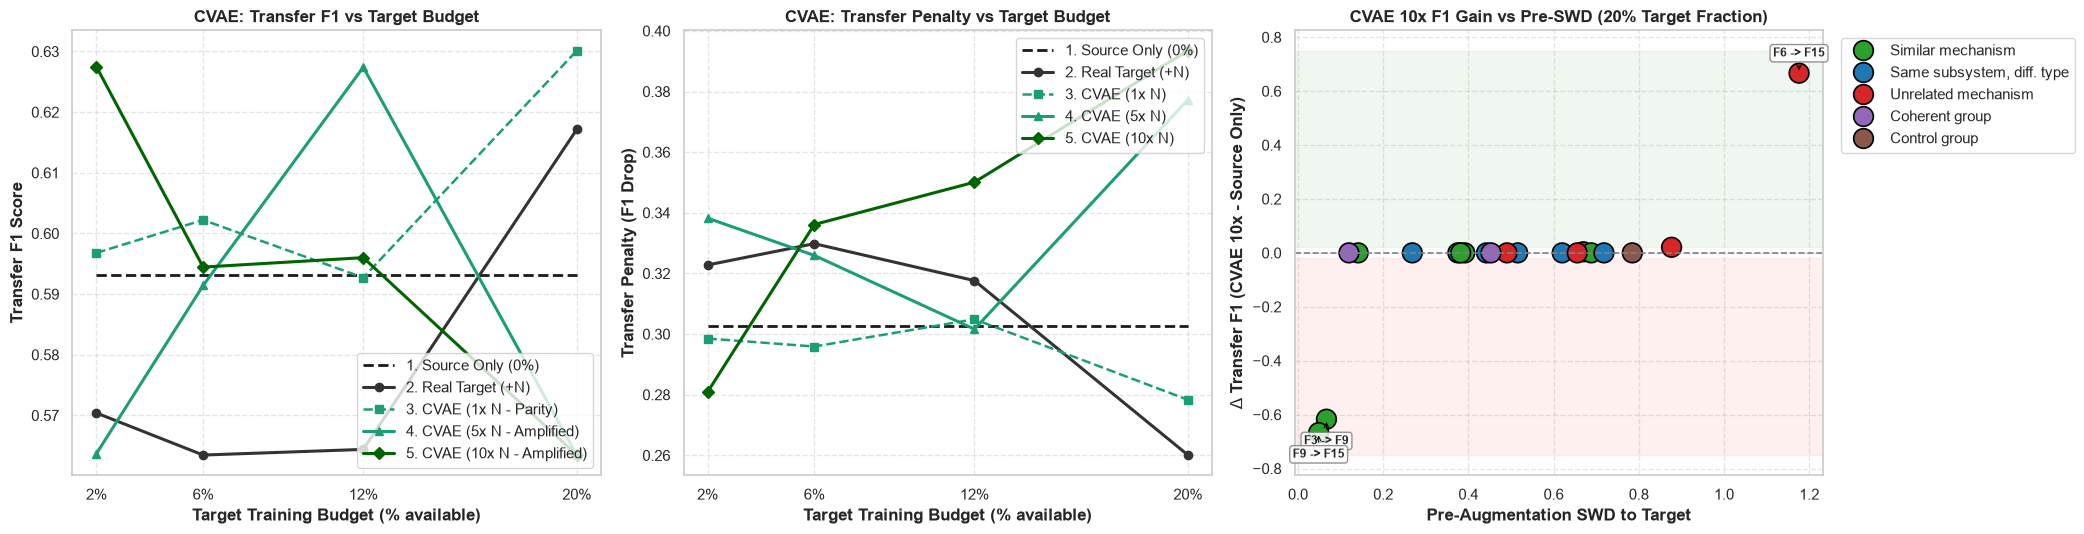

In [ ]:

PAIR_CATEGORY_PALETTE = {
        'Similar mechanism': '#1b9e77',
        'Same subsystem, diff. type': '#377eb8',
        'Unrelated mechanism': '#e41a1c',
        'Coherent group': '#984ea3',
        'Control group': '#a65628'
    }
fig, axes = plt.subplots(1, 3, figsize=(21, 5.5))

# ── 1. Preparazione dei dati medi per percentuale budget ────────────────────
avg_pct = df_binary_budget.groupby('Percent').mean(numeric_only=True).reset_index()
pct_ticks = sorted(avg_pct['Percent'].unique())
pct_labels = [f"{int(p) if p.is_integer() else p:.0f}%" for p in pct_ticks]

# ── Plot 1: Transfer F1 vs Target Budget (CVAE 1x, 5x, 10x) ─────────────────
axes[0].plot(avg_pct['Percent'], avg_pct['F1_Source_Only'], 'k--', lw=2, label='1. Source Only (0%)')
axes[0].plot(avg_pct['Percent'], avg_pct['F1_Real_N'], 'o-', color='#333333', lw=2.2, label='2. Real Target (+N)')
axes[0].plot(avg_pct['Percent'], avg_pct['F1_CVAE_1x'], 's--', color='#1b9e77', lw=1.8, label='3. CVAE (1x N - Parity)')
axes[0].plot(avg_pct['Percent'], avg_pct['F1_CVAE_5x'], '^-', color='#1b9e77', lw=2.2, label='4. CVAE (5x N - Amplified)')
axes[0].plot(avg_pct['Percent'], avg_pct['F1_CVAE_10x'], 'D-', color='#006400', lw=2.2, label='5. CVAE (10x N - Amplified)')

axes[0].set_title('CVAE: Transfer F1 vs Target Budget', fontweight='bold')
axes[0].set_xlabel('Target Training Budget (% available)', fontweight='semibold')
axes[0].set_ylabel('Transfer F1 Score', fontweight='semibold')
axes[0].set_xticks(pct_ticks)
axes[0].set_xticklabels(pct_labels)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='lower right')

# ── Plot 2: Transfer Penalty Reduction vs Target Budget ──────────────────────
axes[1].plot(avg_pct['Percent'], avg_pct['Penalty_Source_Only'], 'k--', lw=2, label='1. Source Only (0%)')
axes[1].plot(avg_pct['Percent'], avg_pct['Penalty_Real_N'], 'o-', color='#333333', lw=2.2, label='2. Real Target (+N)')
axes[1].plot(avg_pct['Percent'], avg_pct['Penalty_CVAE_1x'], 's--', color='#1b9e77', lw=1.8, label='3. CVAE (1x N)')
axes[1].plot(avg_pct['Percent'], avg_pct['Penalty_CVAE_5x'], '^-', color='#1b9e77', lw=2.2, label='4. CVAE (5x N)')
axes[1].plot(avg_pct['Percent'], avg_pct['Penalty_CVAE_10x'], 'D-', color='#006400', lw=2.2, label='5. CVAE (10x N)')

axes[1].set_title('CVAE: Transfer Penalty vs Target Budget', fontweight='bold')
axes[1].set_xlabel('Target Training Budget (% available)', fontweight='semibold')
axes[1].set_ylabel('Transfer Penalty (F1 Drop)', fontweight='semibold')
axes[1].set_xticks(pct_ticks)
axes[1].set_xticklabels(pct_labels)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc='upper right')

# ── Plot 3: F1 Gain vs Pre-Augmentation SWD con Annotazioni e Quadranti ──────
max_pct = df_binary_budget['Percent'].max()
df_p_max = df_binary_budget[df_binary_budget['Percent'] == max_pct].copy()

# Fasce colorate di sfondo (Verde = Guadagno, Rosso = Perdita)
axes[2].axhspan(0.02, 0.75, color='green', alpha=0.06)
axes[2].axhspan(-0.75, -0.02, color='red', alpha=0.06)
axes[2].axhline(0, color='gray', linestyle='--', linewidth=1.2)

# Scatter Plot con punti evidenziati
sns.scatterplot(
    data=df_p_max, x='Pre_SWD', y='Gain_CVAE_10x', hue='Category',
    palette=PAIR_CATEGORY_PALETTE, s=200, edgecolor='black', linewidth=1.2, ax=axes[2]
)

# Rilevamento automatico della colonna del nome del Pair ('Pair' o 'name')
pair_col = 'Pair' if 'Pair' in df_p_max.columns else 'name'

for _, row in df_p_max.iterrows():
    if abs(row['Gain_CVAE_10x']) > 0.03 or row['Pre_SWD'] > 1.0:
        offset_y = 12 if row['Gain_CVAE_10x'] >= 0 else -18
        axes[2].annotate(
            row[pair_col], 
            (row['Pre_SWD'], row['Gain_CVAE_10x']),
            textcoords="offset points", 
            xytext=(0, offset_y),
            ha='center', fontsize=8.5, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.85),
            arrowprops=dict(arrowstyle="->", color="black", lw=0.7)
        )

axes[2].set_title(f'CVAE 10x F1 Gain vs Pre-SWD ({max_pct:.0f}% Target Fraction)', fontweight='bold')
axes[2].set_xlabel('Pre-Augmentation SWD to Target', fontweight='semibold')
axes[2].set_ylabel(r'$\Delta$ Transfer F1 (CVAE 10x - Source Only)', fontweight='semibold')
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.show()




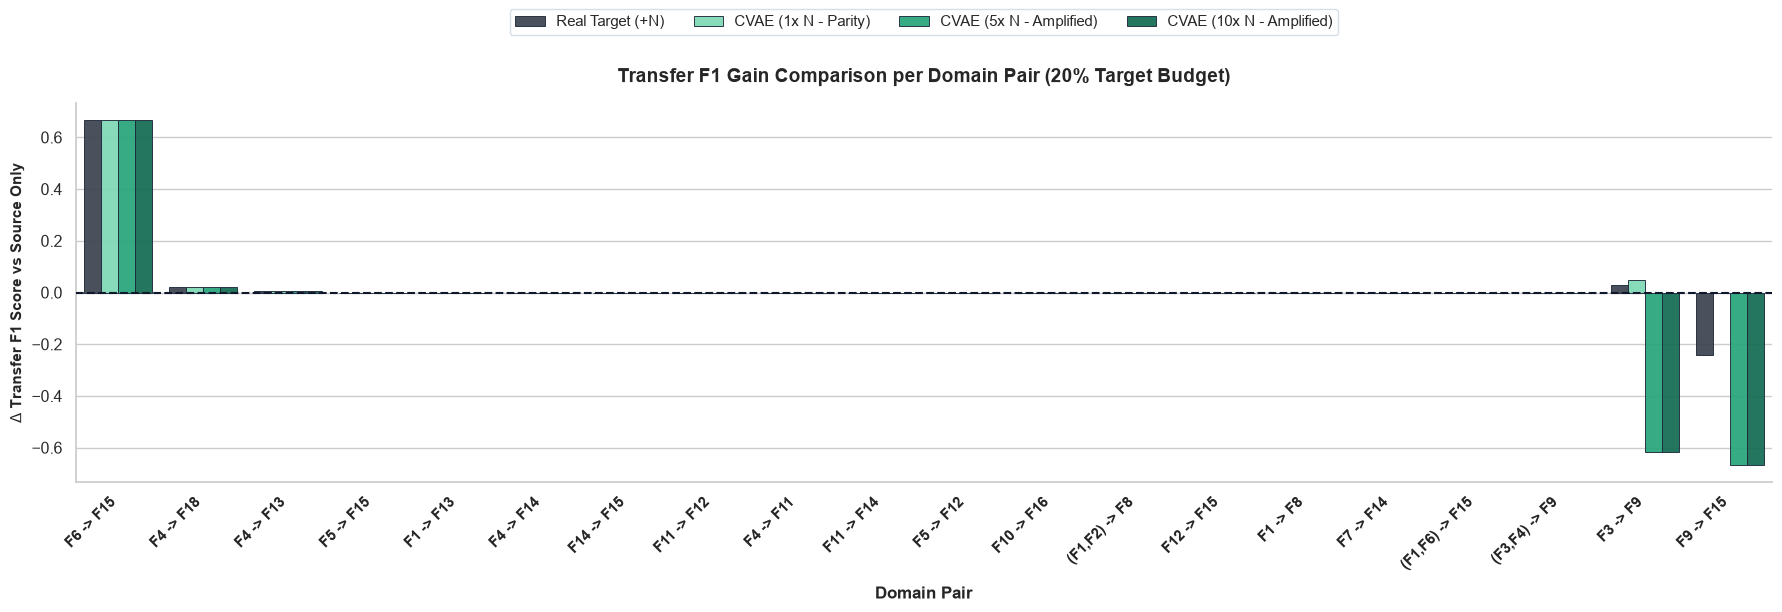

In [ ]:
sns.set_theme(style="whitegrid", font_scale=1.05)

max_pct = df_binary_budget['Percent'].max()
df_p_max = df_binary_budget[df_binary_budget['Percent'] == max_pct].copy()

if 'Gain_Real_N' not in df_p_max.columns:
    df_p_max['Gain_Real_N'] = df_p_max['F1_Real_N'] - df_p_max['F1_Source_Only']

pair_col = 'Pair' if 'Pair' in df_p_max.columns else 'name'

df_melted = df_p_max.melt(
    id_vars=[pair_col, 'Category'],
    value_vars=['Gain_Real_N', 'Gain_CVAE_1x', 'Gain_CVAE_5x', 'Gain_CVAE_10x'],
    var_name='Scenario',
    value_name='F1_Gain'
)

scenario_map = {
    'Gain_Real_N':  'Real Target (+N)',
    'Gain_CVAE_1x':  'CVAE (1x N - Parity)',
    'Gain_CVAE_5x':  'CVAE (5x N - Amplified)',
    'Gain_CVAE_10x': 'CVAE (10x N - Amplified)'
}
df_melted['Scenario'] = df_melted['Scenario'].map(scenario_map)

pair_order = df_p_max.sort_values(by='Gain_CVAE_10x', ascending=False)[pair_col].tolist()

scenario_palette = {
    'Real Target (+N)':          '#374151',  # Antracite
    'CVAE (1x N - Parity)':     '#6EE7B7',  # Verde Menta
    'CVAE (5x N - Amplified)':  '#10B981',  # Verde Smeraldo
    'CVAE (10x N - Amplified)': '#047857'   # Verde Foresta
}

fig, ax = plt.subplots(figsize=(18, 6.5))

sns.barplot(
    data=df_melted, x=pair_col, y='F1_Gain', hue='Scenario',
    order=pair_order, palette=scenario_palette,
    edgecolor='#1e293b', linewidth=0.7, alpha=0.92, ax=ax, zorder=2
)

# Linea orizzontale dello zero di riferimento
ax.axhline(0, color='#0f172a', linestyle='--', linewidth=1.5, zorder=3)


ax.set_title(
    f'Transfer F1 Gain Comparison per Domain Pair ({max_pct:.0f}% Target Budget)',
    fontsize=14, fontweight='bold', pad=15
)

ax.legend(
    bbox_to_anchor=(0.5, 1.16), loc='lower center', ncol=4,
    title='', frameon=True, facecolor='white', edgecolor='#cbd5e1', fontsize=10.5
)

ax.set_xlabel('Domain Pair', fontweight='bold', fontsize=12, labelpad=10)
ax.set_ylabel(r'$\Delta$ Transfer F1 Score vs Source Only', fontweight='bold', fontsize=11)

plt.xticks(rotation=45, ha='right', fontweight='semibold', fontsize=10.5)

# Rimozione dei bordi superflui
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()


# PART II: Multiclass Synthetic Augmentation (Fault Diagnosis Track)

In this track, we address **Fault Diagnosis** ($y \in \{0..5\}$), evaluating how well class-conditional generative models restore multiclass separation and per-mechanism recall across structured domain gaps.

### Deterministic Disturbance Mechanism Mapping (0..5)
Directly imported from Stage 2:

| Class ID | Mechanism Name | Included Fault IDs | Physical Description |
|---|---|---|---|
| **Class 0** | Normal State | $F0$ | Nominal steady-state operation |
| **Class 1** | Step Disturbances | $F1 \dots F7$ | Abrupt step jumps in feed flow, temperature, and cooling |
| **Class 2** | Random Variations | $F8 \dots F12$ | Persistent stochastic fluctuations in process variables |
| **Class 3** | Slow Dynamic Drift | $F13$ | Slow reaction kinetics drift in reactant C |
| **Class 4** | Actuator Stiction | $F14 \dots F15$ | Mechanical valve stiction and nonlinear actuator dynamics |
| **Class 5** | Unknown Disturbances | $F16 \dots F20$ | Unmodeled plant perturbations and unknown dynamics |


In [ ]:
# ── Disturbance Mechanism Mapping (Exact Stage 2 Taxonomy) ───────────────────
MECHANISM_MAP = {
    0:  (0, 'Normal', 'Nominal steady-state operation'),
    1:  (1, 'Step Disturbance', 'Faults 1-7: Abrupt step jumps in feed and cooling'),
    2:  (1, 'Step Disturbance', 'Faults 1-7'),
    3:  (1, 'Step Disturbance', 'Faults 1-7'),
    4:  (1, 'Step Disturbance', 'Faults 1-7'),
    5:  (1, 'Step Disturbance', 'Faults 1-7'),
    6:  (1, 'Step Disturbance', 'Faults 1-7'),
    7:  (1, 'Step Disturbance', 'Faults 1-7'),
    8:  (2, 'Random Variation', 'Faults 8-12: Persistent stochastic fluctuations'),
    9:  (2, 'Random Variation', 'Faults 8-12'),
    10: (2, 'Random Variation', 'Faults 8-12'),
    11: (2, 'Random Variation', 'Faults 8-12'),
    12: (2, 'Random Variation', 'Faults 8-12'),
    13: (3, 'Slow Dynamic Drift', 'Fault 13: Reaction kinetics drift in reactant C'),
    14: (4, 'Actuator Stiction', 'Faults 14-15: Mechanical valve stiction & nonlinearities'),
    15: (4, 'Actuator Stiction', 'Faults 14-15'),
    16: (5, 'Unknown Perturbation', 'Faults 16-20: Unmodeled plant disturbances'),
    17: (5, 'Unknown Perturbation', 'Faults 16-20'),
    18: (5, 'Unknown Perturbation', 'Faults 16-20'),
    19: (5, 'Unknown Perturbation', 'Faults 16-20'),
    20: (5, 'Unknown Perturbation', 'Faults 16-20'),
}

MECHANISM_NAMES = {
    0: '0: Normal',
    1: '1: Step Disturbances (F1-7)',
    2: '2: Random Variations (F8-12)',
    3: '3: Slow Drift (F13)',
    4: '4: Actuator Stiction (F14-15)',
    5: '5: Unknown Disturbances (F16-20)',
}

NUM_CLASSES_MULTICLASS = 6

def map_fault_to_mechanism(fault_id: int) -> int:
    """Map TEP fault ID (0..20) to physical disturbance mechanism category (0..5).

    Args:
        fault_id (int): TEP fault ID.

    Returns:
        int: Mechanism category index (0..5).
    """
    return MECHANISM_MAP.get(fault_id, (0, 'Normal'))[0]

def get_mechanism_features(split='train'):
    X_list, y_list = [], []
    for f in range(21):
        feats = DOMAIN_FEATURES[f][split]
        if len(feats) > 0:
            X_list.append(feats)
            y_list.append(np.full(len(feats), map_fault_to_mechanism(f)))
    return np.vstack(X_list), np.concatenate(y_list)

X_mech_train, y_mech_train = get_mechanism_features('train')
X_mech_test,  y_mech_test  = get_mechanism_features('test')

print(f'Multiclass Dataset Shapes -> Train: {X_mech_train.shape} | Test: {X_mech_test.shape}')
for c in range(NUM_CLASSES_MULTICLASS):
    print(f'  Class {c} ({MECHANISM_NAMES[c]}): {np.sum(y_mech_train == c)} train windows | {np.sum(y_mech_test == c)} test windows')

Multiclass Dataset Shapes -> Train: (38640, 208) | Test: (79430, 208)
  Class 0 (0: Normal): 1840 train windows | 3900 test windows
  Class 1 (1: Step Disturbances (F1-7)): 12880 train windows | 27300 test windows
  Class 2 (2: Random Variations (F8-12)): 9200 train windows | 19500 test windows
  Class 3 (3: Slow Drift (F13)): 1840 train windows | 3900 test windows
  Class 4 (4: Actuator Stiction (F14-15)): 3680 train windows | 5330 test windows
  Class 5 (5: Unknown Disturbances (F16-20)): 9200 train windows | 19500 test windows


### 6. Multiclass Conditional Generative Models (CVAE & CGAN)

Generators condition on the concatenation of the **one-hot mechanism label** and continuous **domain indicator** $\alpha$:
$$\mathbf{c} = [\text{one\_hot}(c_0, \dots, c_5) \;\Vert\; \alpha]$$

In [38]:
INPUT_DIM = 208
LATENT_DIM = 24
HIDDEN_DIM = 128

class MulticlassCVAE(nn.Module):
    """
    Multiclass CVAE con architettura a 128 neuroni latenti e BatchNorm1d.
    Condizionata con la classe one-hot (6D) + indicatore di dominio alpha (1D).
    """
    def __init__(self, input_dim=INPUT_DIM, num_classes=NUM_CLASSES_MULTICLASS, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.latent_dim = latent_dim
        cond_dim = num_classes + 1  # 6 classes + 1 domain indicator
        
        # Encoder: 208 + 7 = 215 in -> 128 -> 128 -> 24D latent space (mu, logvar)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim + cond_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_lv = nn.Linear(hidden_dim, latent_dim)
        
        # Decoder: 24 + 7 = 31 in -> 128 -> 128 -> 208 out
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, input_dim),
        )

    def encode(self, x, c):
        h = self.encoder(torch.cat([x, c], dim=1))
        return self.fc_mu(h), self.fc_lv(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, c):
        return self.decoder(torch.cat([z, c], dim=1))

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, c), mu, logvar
    
def cvae_loss(recon_x: torch.Tensor, x: torch.Tensor, mu: torch.Tensor, logvar: torch.Tensor, beta: float = 1e-5) -> torch.Tensor:
        """Compute CVAE loss combining L1 reconstruction error and KL divergence.

        Args:
            recon_x (torch.Tensor): Reconstructed feature batch.
            x (torch.Tensor): Ground truth target feature batch.
            mu (torch.Tensor): Latent mean vector.
            logvar (torch.Tensor): Latent log variance vector.
            beta (float): KL divergence weight hyperparameter.

        Returns:
            torch.Tensor: Scalar loss tensor.
        """

        l1 = nn.functional.l1_loss(recon_x, x, reduction='none').sum(dim=1).mean()
        kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()
        return l1 + beta * kld


class MulticlassCGANGenerator(nn.Module):
    """
    Multiclass CGAN Generator a 128 neuroni con BatchNorm1d.
    """
    def __init__(self, noise_dim=LATENT_DIM, num_classes=NUM_CLASSES_MULTICLASS, hidden_dim=HIDDEN_DIM, output_dim=INPUT_DIM):
        super().__init__()
        cond_dim = num_classes + 1
        self.net = nn.Sequential(
            nn.Linear(noise_dim + cond_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, z, c):
        return self.net(torch.cat([z, c], dim=1))


class MulticlassCGANDiscriminator(nn.Module):
    """
    Multiclass CGAN Discriminator a 128 neuroni.
    """
    def __init__(self, input_dim=INPUT_DIM, num_classes=NUM_CLASSES_MULTICLASS, hidden_dim=HIDDEN_DIM):
        super().__init__()
        cond_dim = num_classes + 1
        self.net = nn.Sequential(
            nn.Linear(input_dim + cond_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x, c):
        return self.net(torch.cat([x, c], dim=1))

### 7. Multiclass Budget-Controlled Experiment (8 Structured Pairs)

We evaluate multiclass synthetic augmentation across the **8 structured cross-mechanism domain pairs** curated in Stage 2.

In [ ]:
MULTICLASS_PAIRS = [
    {
        'name': 'Step Disturbances vs Actuator Stiction',
        'source_faults': [1, 2, 4, 7],             # 4 faults (Cat 1: Feed & Cooling step jumps)
        'target_faults': [14, 15],                  # 2 faults (Cat 4: Valve stiction)
        'source_split': 'train',
        'target_split': 'test',
        'category': 'Inter-Category: Feed/Cooling to Mechanical Stiction'
    },
    {
        'name': 'Full Random Variations -> Full Slow Dynamic Drift',
        'source_faults': [8, 9, 10, 11, 12],              # Full Category 2 (5 faults)
        'target_faults': [13],                            # Full Category 3 (1 fault)
        'source_split': 'train',
        'target_split': 'test',
        'category': 'Inter-Category (Full Cat 2 -> Full Cat 3)'
    },
    {
        'name': 'Mixed Source to Unknown Perturbations',
        'source_faults': [2, 5, 8, 11],             # 4 mixed source faults (Cat 1 + Cat 2)
        'target_faults': [17, 18],              # 2 target faults (Cat 5: Unmodeled plant disturbances)
        'source_split': 'train',
        'target_split': 'test',
        'category': 'Asymmetric Transfer: Mixed Multi-Mechanism to Unknowns'
    },
    {
        'name': 'Actuator Stiction vs Random Variations',
        'source_faults': [14, 15],                  # 2 faults (Cat 4: Valves)
        'target_faults': [9, 10, 12],            # 3 faults (Cat 2: Stochastic fluctuations)
        'source_split': 'train',
        'target_split': 'test',
        'category': 'Inverse Flow: Mechanical to Stochastic Dynamics'
    },
    {
        'name': 'Expanded Step Disturbances vs Extended Unknowns',
        'source_faults': [1, 3, 5, 6],              # 4 faults (Cat 1)
        'target_faults': [19, 20],          # 2 faults (Cat 5)
        'source_split': 'train',
        'target_split': 'test',
        'category': 'Symmetric Cross-Domain: Feed Disruptions to Plant Perturbations'
    }
]

CVAE_TEMPERATURE = 2.0  

TARGET_PERCENT_GRID_MULTICLASS = [0.1, 0.06, 0.15]


def train_multiclass_cvae(X_src: np.ndarray, y_src: np.ndarray, X_tgt_budget: np.ndarray, y_tgt_budget: np.ndarray, n_epochs: int = 50, beta: float = 1e-5):
    """Train Multiclass CVAE on combined Source and Target budget observations.

    Args:
        X_src (np.ndarray): Source feature matrix.
        y_src (np.ndarray): Source mechanism labels.
        X_tgt_budget (np.ndarray): Limited target budget feature matrix.
        y_tgt_budget (np.ndarray): Limited target budget mechanism labels.
        n_epochs (int): Number of training epochs.
        beta (float): KL loss weight hyperparameter.

    Returns:
        tuple[MulticlassCVAE, StandardScaler]: Trained CVAE model and fitted feature scaler.
    """

    X_all_pair = np.vstack([X_src, X_tgt_budget])
    sc = StandardScaler().fit(X_all_pair)
    sc.scale_ = np.maximum(sc.scale_, 1e-5)
    X_sc = sc.transform(X_all_pair)
    
    y_all_pair = np.concatenate([y_src, y_tgt_budget])
    
    y_oh = np.eye(NUM_CLASSES_MULTICLASS)[y_all_pair.astype(int)]
    c_domain = np.concatenate([np.zeros(len(X_src)), np.ones(len(X_tgt_budget))]).reshape(-1, 1)
    c_cond = np.hstack([y_oh, c_domain]).astype(np.float32)
    
    dataset = TensorDataset(torch.tensor(X_sc, dtype=torch.float32), torch.tensor(c_cond, dtype=torch.float32))
    ld = DataLoader(dataset, batch_size=64, shuffle=True, drop_last=False)
    
    # Addestramento deterministico con set_seed
    set_seed(SEED)
    m_vae = MulticlassCVAE(input_dim=X_sc.shape[1], num_classes=NUM_CLASSES_MULTICLASS, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM).to(DEVICE)
    opt_v = optim.Adam(m_vae.parameters(), lr=1e-3)
    
    m_vae.train()
    for _ in range(n_epochs):
        for xb, cb in ld:
            xb, cb = xb.to(DEVICE), cb.to(DEVICE)
            opt_v.zero_grad()
            rec, mu, lv = m_vae(xb, cb)
            loss = cvae_loss(rec, xb, mu, lv, beta=beta)
            loss.backward()
            opt_v.step()

    m_vae.eval()
    return m_vae, sc


def eval_multiclass_rf(X_aug, y_aug, X_target_test, y_target_test):
    """Evaluates Multiclass Random Forest classifier on frozen target test set computing Macro F1 and Transfer Penalty.

    Args
    X_aug : np.ndarray
        Augmented feature matrix (Source + Target/Synthetic).
    y_aug : np.ndarray
        Augmented mechanism class labels.
    X_target_test : np.ndarray
        Frozen target test feature matrix.
    y_target_test : np.ndarray
        Frozen target test mechanism class labels.

    Returns
    tuple of (float, float, float, float, float)
        Baseline Macro F1, Transfer Macro F1, Baseline Accuracy, Transfer Accuracy, and Transfer Penalty.
    """
    Xtr, Xte, ytr, yte = train_test_split(
        X_aug, y_aug, test_size=0.2, random_state=SEED, stratify=y_aug
    )
    rf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
    rf.fit(Xtr, ytr)
    
    all_labels = np.unique(np.concatenate([yte, y_target_test]))
    
    # Macro F1-Score bilanciato su tutte le classi
    bl_f1  = f1_score(yte, rf.predict(Xte), labels=all_labels, average='macro', zero_division=0)
    tr_f1  = f1_score(y_target_test, rf.predict(X_target_test), labels=all_labels, average='macro', zero_division=0)
    
    # Balanced Accuracy Score
    bl_acc = balanced_accuracy_score(yte, rf.predict(Xte))
    tr_acc = balanced_accuracy_score(y_target_test, rf.predict(X_target_test))
    
    penalty_f1 = bl_f1 - tr_f1
    return bl_f1, tr_f1, bl_acc, tr_acc, penalty_f1

In [ ]:
CVAE_TEMPERATURE = 2.0  

mc_budget_records = []

for pair in tqdm(MULTICLASS_PAIRS, desc='Evaluating 20 Multiclass Pairs'):
    set_seed(SEED)
    rng = np.random.default_rng(SEED)
    
    print(f"\n\nPAIR = {pair['name']} | PAIR CATEGORY = {pair['category']}")

    src_raw = pair.get('source', pair.get('source_faults', []))
    tgt_raw = pair.get('target', pair.get('target_faults', []))

    src_faults = src_raw if isinstance(src_raw, list) else [src_raw]
    tgt_faults = tgt_raw if isinstance(tgt_raw, list) else [tgt_raw]

    X_src_norm_tr = DOMAIN_FEATURES[0]['train']
    src_anom_combined = np.vstack([DOMAIN_FEATURES[f]['train'] for f in src_faults])
    y_src_anom = np.concatenate([np.full(len(DOMAIN_FEATURES[f]['train']), map_fault_to_mechanism(f)) for f in src_faults])
    
    X_src = np.vstack([X_src_norm_tr, src_anom_combined])
    y_src = np.concatenate([np.zeros(len(X_src_norm_tr)), y_src_anom])

    X_tgt_test = np.vstack([DOMAIN_FEATURES[0]['test']] + [DOMAIN_FEATURES[f]['test'] for f in tgt_faults])
    y_tgt_test = np.concatenate([np.zeros(len(DOMAIN_FEATURES[0]['test']))] + [np.full(len(DOMAIN_FEATURES[f]['test']), map_fault_to_mechanism(f)) for f in tgt_faults])

    X_tgt_train_anom = np.vstack([DOMAIN_FEATURES[f]['train'] for f in tgt_faults])
    y_tgt_train_anom = np.concatenate([np.full(len(DOMAIN_FEATURES[f]['train']), map_fault_to_mechanism(f)) for f in tgt_faults])
    total_tgt_train  = len(X_tgt_train_anom)

    all_tr_data = np.vstack([src_anom_combined, X_tgt_train_anom])
    scaler = StandardScaler().fit(all_tr_data)
    scaler.scale_ = np.maximum(scaler.scale_, 1e-3)

    X_src_sc = scaler.transform(X_src)
    src_anom_combined_sc = scaler.transform(src_anom_combined)
    X_tgt_train_anom_sc  = scaler.transform(X_tgt_train_anom)

    margin = 0.20 * (all_tr_data.max(axis=0) - all_tr_data.min(axis=0))
    lower_bound = scaler.transform((all_tr_data.min(axis=0) - margin).reshape(1, -1)).squeeze()
    upper_bound = scaler.transform((all_tr_data.max(axis=0) + margin).reshape(1, -1)).squeeze()

    pre_dist = compute_distances(src_anom_combined_sc, X_tgt_train_anom_sc)

    # Scenario 1: Source-only Baseline
    _, tr_src, _, _, pen_src = eval_multiclass_rf(X_src_sc, y_src, X_tgt_test, y_tgt_test)
    print(f'Scenario 1 - Source-only Baseline | Target F1: {tr_src:.4f} | Penalty: {pen_src:.4f} | SWD: {pre_dist["SWD"]:.4f} | MMD: {pre_dist["MMD"]:.4f} | FD: {pre_dist["FD"]:.4f}')

    for pct in TARGET_PERCENT_GRID_MULTICLASS:
        N = max(10, int(np.round(pct * total_tgt_train)))
        print(f'\n{N} samples ({pct*100:.0f}%)')

        idx = rng.choice(total_tgt_train, N, replace=False)
        tgt_budget_anom = X_tgt_train_anom[idx]
        tgt_budget_anom_sc = scaler.transform(tgt_budget_anom)
        y_tgt_budget = y_tgt_train_anom[idx]

        # Scenario 2: Source + Real Target (+N Reali)
        X_real_sc = np.vstack([X_src_sc, tgt_budget_anom_sc])
        y_real = np.concatenate([y_src, y_tgt_budget])

        _, tr_real, _, _, pen_real = eval_multiclass_rf(X_real_sc, y_real, X_tgt_test, y_tgt_test)
        dist_real = compute_distances(tgt_budget_anom_sc, X_tgt_train_anom_sc)
        print(f'Scenario 2 - Source + {N} Real Target (1x) | Target F1: {tr_real:.4f} | Penalty: {pen_real:.4f} | SWD: {dist_real["SWD"]:.4f} | MMD: {dist_real["MMD"]:.4f} | FD: {dist_real["FD"]:.4f}')

        set_seed(SEED)
        m_mc_vae, sc_mc = train_multiclass_cvae(X_src, y_src, tgt_budget_anom, y_tgt_budget, n_epochs=50, beta=1e-5)

        tgt_classes, counts = np.unique(y_tgt_budget, return_counts=True)
        
        syn_1x_list, lbl_1x_list = [], []
        syn_5x_list, lbl_5x_list = [], []
        syn_10x_list, lbl_10x_list = [], []

        m_mc_vae.eval()
        with torch.no_grad():
            for tc, cnt in zip(tgt_classes, counts):
                oh_class = np.eye(NUM_CLASSES_MULTICLASS)[int(tc)]
                
                n1 = max(1, int(np.round(1 * cnt)))
                c1 = torch.tensor(np.tile(np.append(oh_class, 1.0), (n1, 1)), dtype=torch.float32, device=DEVICE)
                zv1 = torch.randn(n1, LATENT_DIM, device=DEVICE) * CVAE_TEMPERATURE
                syn1 = np.clip(m_mc_vae.decode(zv1, c1).cpu().numpy(), lower_bound, upper_bound)
                syn_1x_list.append(syn1)
                lbl_1x_list.append(np.full(n1, tc))

                n5 = max(1, int(np.round(5 * cnt)))
                c5 = torch.tensor(np.tile(np.append(oh_class, 1.0), (n5, 1)), dtype=torch.float32, device=DEVICE)
                zv5 = torch.randn(n5, LATENT_DIM, device=DEVICE) * CVAE_TEMPERATURE
                syn5 = np.clip(m_mc_vae.decode(zv5, c5).cpu().numpy(), lower_bound, upper_bound)
                syn_5x_list.append(syn5)
                lbl_5x_list.append(np.full(n5, tc))

                n10 = max(1, int(np.round(10 * cnt)))
                c10 = torch.tensor(np.tile(np.append(oh_class, 1.0), (n10, 1)), dtype=torch.float32, device=DEVICE)
                zv10 = torch.randn(n10, LATENT_DIM, device=DEVICE) * CVAE_TEMPERATURE
                syn10 = np.clip(m_mc_vae.decode(zv10, c10).cpu().numpy(), lower_bound, upper_bound)
                syn_10x_list.append(syn10)
                lbl_10x_list.append(np.full(n10, tc))

        syn_v1 = np.vstack(syn_1x_list)
        lbl_v1 = np.concatenate(lbl_1x_list)
        
        syn_v5 = np.vstack(syn_5x_list)
        lbl_v5 = np.concatenate(lbl_5x_list)
        
        syn_v10 = np.vstack(syn_10x_list)
        lbl_v10 = np.concatenate(lbl_10x_list)

        # Scenario 3: Source + Synthetic 1x N
        X_v1_sc = np.vstack([X_src_sc, syn_v1])
        y_v1 = np.concatenate([y_src, lbl_v1])
        _, tr_v1, _, _, pen_v1 = eval_multiclass_rf(X_v1_sc, y_v1, X_tgt_test, y_tgt_test)
        dist_v1 = compute_distances(syn_v1, X_tgt_train_anom_sc)
        print(f'Scenario 3 - Source + {N} Synthetic (1x) | Target F1: {tr_v1:.4f} | Penalty: {pen_v1:.4f} | SWD: {dist_v1["SWD"]:.4f} | MMD: {dist_v1["MMD"]:.4f} | FD: {dist_v1["FD"]:.4f}')

        # Scenario 4: Source + Synthetic 5x N
        X_v5_sc = np.vstack([X_src_sc, syn_v5])
        y_v5 = np.concatenate([y_src, lbl_v5])
        _, tr_v5, _, _, pen_v5 = eval_multiclass_rf(X_v5_sc, y_v5, X_tgt_test, y_tgt_test)
        dist_v5 = compute_distances(syn_v5, X_tgt_train_anom_sc)
        print(f'Scenario 4 - Source + {5 * N} Synthetic (5x) | Target F1: {tr_v5:.4f} | Penalty: {pen_v5:.4f} | SWD: {dist_v5["SWD"]:.4f} | MMD: {dist_v5["MMD"]:.4f} | FD: {dist_v5["FD"]:.4f}')

        # Scenario 5: Source + Synthetic 10x N
        X_v10_sc = np.vstack([X_src_sc, syn_v10])
        y_v10 = np.concatenate([y_src, lbl_v10])
        _, tr_v10, _, _, pen_v10 = eval_multiclass_rf(X_v10_sc, y_v10, X_tgt_test, y_tgt_test)
        dist_v10 = compute_distances(syn_v10, X_tgt_train_anom_sc)
        print(f'Scenario 5 - Source + {10 * N} Synthetic (10x) | Target F1: {tr_v10:.4f} | Penalty: {pen_v10:.4f} | SWD: {dist_v10["SWD"]:.4f} | MMD: {dist_v10["MMD"]:.4f} | FD: {dist_v10["FD"]:.4f}')

        # Registrazione Record
        mc_budget_records.append({
            'Pair': pair['name'], 'Category': pair['category'], 'Percent': pct * 100, 'N': N,
            'Pre_SWD': pre_dist['SWD'], 'Pre_MMD': pre_dist['MMD'], 'Pre_FD': pre_dist['FD'],
            # Scenario 1: Source only
            'F1_Source_Only': tr_src, 'Penalty_Source_Only': pen_src,
            # Scenario 2: Real N
            'F1_Real_N': tr_real, 'Penalty_Real_N': pen_real, 'SWD_Real_N': dist_real['SWD'], 'MMD_Real_N': dist_real['MMD'], 'FD_Real_N': dist_real['FD'],
            # Scenario 3: Synth 1x N (Parity)
            'F1_CVAE_1x': tr_v1, 'Penalty_CVAE_1x': pen_v1, 'SWD_CVAE_1x': dist_v1['SWD'], 'MMD_CVAE_1x': dist_v1['MMD'], 'FD_CVAE_1x': dist_v1['FD'],
            # Scenario 4: Synth 5x N (Amplification)
            'F1_CVAE_5x': tr_v5, 'Penalty_CVAE_5x': pen_v5, 'SWD_CVAE_5x': dist_v5['SWD'], 'MMD_CVAE_5x': dist_v5['MMD'], 'FD_CVAE_5x': dist_v5['FD'],
            # Scenario 5: Synth 10x N (Amplification)
            'F1_CVAE_10x': tr_v10, 'Penalty_CVAE_10x': pen_v10, 'SWD_CVAE_10x': dist_v10['SWD'], 'MMD_CVAE_10x': dist_v10['MMD'], 'FD_CVAE_10x': dist_v10['FD'],
            
            'Gain_CVAE_1x': tr_v1 - tr_src,
            'Gain_CVAE_5x': tr_v5 - tr_src,
            'Gain_CVAE_10x': tr_v10 - tr_src,
        })

df_mc_budget = pd.DataFrame(mc_budget_records)

summary_mc = df_mc_budget.groupby('Percent').agg({
    'N': 'mean',
    'F1_Source_Only': 'mean',
    'F1_Real_N': 'mean',
    'F1_CVAE_1x': 'mean',
    'F1_CVAE_5x': 'mean',
    'F1_CVAE_10x': 'mean',
    'Pre_SWD': 'mean',
    'Pre_MMD': 'mean',
    'Pre_FD': 'mean',
    'SWD_Real_N': 'mean',
    'MMD_Real_N': 'mean',
    'FD_Real_N': 'mean',
    'SWD_CVAE_1x': 'mean',
    'MMD_CVAE_1x': 'mean',
    'FD_CVAE_1x': 'mean',
    'SWD_CVAE_5x': 'mean',
    'MMD_CVAE_5x': 'mean',
    'FD_CVAE_5x': 'mean',
    'SWD_CVAE_10x': 'mean',
    'MMD_CVAE_10x': 'mean',
    'FD_CVAE_10x': 'mean',
}).reset_index()

print('\nMulticlass Summary Table (Averaged across all pairs)')
display(summary_mc.round(4))

Evaluating 20 Multiclass Pairs:   0%|          | 0/5 [00:00<?, ?it/s]



PAIR = Step Disturbances vs Actuator Stiction | PAIR CATEGORY = Inter-Category: Feed/Cooling to Mechanical Stiction
Scenario 1 - Source-only Baseline | Target F1: 0.0000 | Penalty: 0.6667 | SWD: 0.4724 | MMD: 0.1513 | FD: 202.9463

368 samples (10%)
Scenario 2 - Source + 368 Real Target (1x) | Target F1: 0.0000 | Penalty: 0.8811 | SWD: 0.0639 | MMD: 0.0020 | FD: 9.5368
Scenario 3 - Source + 368 Synthetic (1x) | Target F1: 0.0000 | Penalty: 1.0000 | SWD: 0.7771 | MMD: 0.1579 | FD: 433.6030
Scenario 4 - Source + 1840 Synthetic (5x) | Target F1: 0.0000 | Penalty: 1.0000 | SWD: 0.5301 | MMD: 0.1409 | FD: 236.5477
Scenario 5 - Source + 3680 Synthetic (10x) | Target F1: 0.0000 | Penalty: 0.9994 | SWD: 0.4596 | MMD: 0.1206 | FD: 196.6992

221 samples (6%)
Scenario 2 - Source + 221 Real Target (1x) | Target F1: 0.0000 | Penalty: 0.8333 | SWD: 0.0903 | MMD: 0.0041 | FD: 17.3315
Scenario 3 - Source + 221 Synthetic (1x) | Target F1: 0.2440 | Penalty: 0.7520 | SWD: 0.9367 | MMD: 0.1619 | FD: 558

Evaluating 20 Multiclass Pairs:  20%|██        | 1/5 [04:18<17:14, 258.69s/it]

Scenario 5 - Source + 5520 Synthetic (10x) | Target F1: 0.0000 | Penalty: 1.0000 | SWD: 0.4713 | MMD: 0.1153 | FD: 188.8479


PAIR = Full Random Variations -> Full Slow Dynamic Drift | PAIR CATEGORY = Inter-Category (Full Cat 2 -> Full Cat 3)
Scenario 1 - Source-only Baseline | Target F1: 0.0000 | Penalty: 0.2901 | SWD: 0.3681 | MMD: 0.1040 | FD: 124.9486

184 samples (10%)
Scenario 2 - Source + 184 Real Target (1x) | Target F1: 0.2222 | Penalty: 0.2462 | SWD: 0.0812 | MMD: 0.0029 | FD: 14.1935
Scenario 3 - Source + 184 Synthetic (1x) | Target F1: 0.0000 | Penalty: 0.3268 | SWD: 0.3892 | MMD: 0.1224 | FD: 128.2021
Scenario 4 - Source + 920 Synthetic (5x) | Target F1: 0.0000 | Penalty: 0.5883 | SWD: 0.4434 | MMD: 0.1461 | FD: 151.6698
Scenario 5 - Source + 1840 Synthetic (10x) | Target F1: 0.0000 | Penalty: 0.6046 | SWD: 0.4988 | MMD: 0.1629 | FD: 183.3458

110 samples (6%)
Scenario 2 - Source + 110 Real Target (1x) | Target F1: 0.2222 | Penalty: 0.2688 | SWD: 0.1136 | MMD: 0.0057 | FD:

Evaluating 20 Multiclass Pairs:  40%|████      | 2/5 [10:48<16:47, 335.77s/it]

...

Evaluating 20 Multiclass Pairs:  80%|████████  | 4/5 [19:01<04:36, 276.06s/it]

Scenario 5 - Source + 8280 Synthetic (10x) | Target F1: 0.0060 | Penalty: 0.6647 | SWD: 0.3488 | MMD: 0.0511 | FD: 199.3849


PAIR = Expanded Step Disturbances vs Extended Unknowns | PAIR CATEGORY = Symmetric Cross-Domain: Feed Disruptions to Plant Perturbations
Scenario 1 - Source-only Baseline | Target F1: 0.0000 | Penalty: 0.3583 | SWD: 0.5349 | MMD: 0.1345 | FD: 247.0081

368 samples (10%)
Scenario 2 - Source + 368 Real Target (1x) | Target F1: 0.0000 | Penalty: 0.6867 | SWD: 0.0571 | MMD: 0.0018 | FD: 9.4197
Scenario 3 - Source + 368 Synthetic (1x) | Target F1: 0.2667 | Penalty: 0.4374 | SWD: 1.1986 | MMD: 0.2720 | FD: 815.9618
Scenario 4 - Source + 1840 Synthetic (5x) | Target F1: 0.2667 | Penalty: 0.4484 | SWD: 0.7632 | MMD: 0.2756 | FD: 358.1454
Scenario 5 - Source + 3680 Synthetic (10x) | Target F1: 0.2667 | Penalty: 0.4406 | SWD: 0.6409 | MMD: 0.2462 | FD: 272.5796

221 samples (6%)
Scenario 2 - Source + 221 Real Target (1x) | Target F1: 0.0000 | Penalty: 0.6731 | SWD: 0.1003

Evaluating 20 Multiclass Pairs: 100%|██████████| 5/5 [23:28<00:00, 281.71s/it]

Scenario 5 - Source + 5520 Synthetic (10x) | Target F1: 0.2667 | Penalty: 0.4198 | SWD: 0.6290 | MMD: 0.2516 | FD: 246.2282

Multiclass Summary Table (Averaged across all pairs)


,Percent,N,F1_Source_Only,F1_Real_N,F1_CVAE_1x,F1_CVAE_5x,F1_CVAE_10x,Pre_SWD,Pre_MMD,Pre_FD,...,FD_Real_N,SWD_CVAE_1x,MMD_CVAE_1x,FD_CVAE_1x,SWD_CVAE_5x,MMD_CVAE_5x,FD_CVAE_5x,SWD_CVAE_10x,MMD_CVAE_10x,FD_CVAE_10x
0,6.0,220.8,0.0,0.1233,0.1982,0.1991,0.1489,0.4815,0.1167,223.8276,...,16.4901,0.6761,0.1390,414.6540,0.5140,0.1481,236.0663,0.4806,0.1421,209.2256
1,10.0,368.0,0.0,0.1142,0.1432,0.1489,0.0916,0.4815,0.1167,223.8276,...,8.8917,0.6054,0.1401,334.7883,0.4888,0.1413,216.5249,0.4726,0.1352,208.9175
2,15.0,552.0,0.0,0.1352,0.1492,0.1187,0.0612,0.4815,0.1167,223.8276,...,6.6703,0.5840,0.1417,290.5903,0.4889,0.1407,207.5558,0.4938,0.1372,216.6425


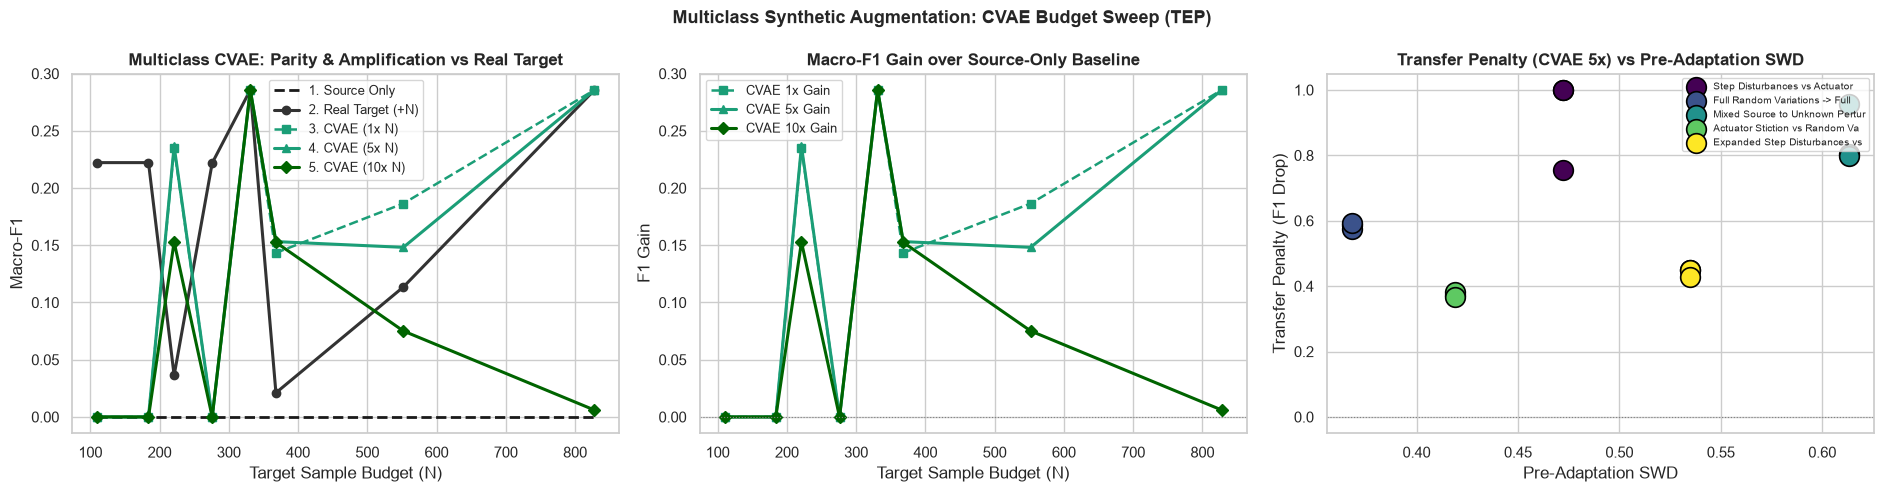

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

avg_mc = df_mc_budget.groupby('N').mean(numeric_only=True).reset_index()

# Panel 1: Macro-F1 vs Budget N
axes[0].plot(avg_mc['N'], avg_mc['F1_Source_Only'], 'k--', lw=2, label='1. Source Only')
axes[0].plot(avg_mc['N'], avg_mc['F1_Real_N'],     'o-',  color='#333333', lw=2.2, label='2. Real Target (+N)')
axes[0].plot(avg_mc['N'], avg_mc['F1_CVAE_1x'],    's--', color='#1b9e77', lw=1.8, label='3. CVAE (1x N)')
axes[0].plot(avg_mc['N'], avg_mc['F1_CVAE_5x'],    '^-',  color='#1b9e77', lw=2.2, label='4. CVAE (5x N)')
axes[0].plot(avg_mc['N'], avg_mc['F1_CVAE_10x'],   'D-',  color='#006400', lw=2.2, label='5. CVAE (10x N)')
axes[0].set_title('Multiclass CVAE: Parity & Amplification vs Real Target', fontweight='bold')
axes[0].set_xlabel('Target Sample Budget (N)')
axes[0].set_ylabel('Macro-F1')
axes[0].legend(fontsize=9)

# Panel 2: F1 Gain vs Budget N
axes[1].plot(avg_mc['N'], avg_mc['Gain_CVAE_1x'],  's--', color='#1b9e77', lw=1.8, label='CVAE 1x Gain')
axes[1].plot(avg_mc['N'], avg_mc['Gain_CVAE_5x'],  '^-',  color='#1b9e77', lw=2.2, label='CVAE 5x Gain')
axes[1].plot(avg_mc['N'], avg_mc['Gain_CVAE_10x'], 'D-',  color='#006400', lw=2.2, label='CVAE 10x Gain')
axes[1].axhline(0, color='gray', lw=0.8, ls=':')
axes[1].set_title('Macro-F1 Gain over Source-Only Baseline', fontweight='bold')
axes[1].set_xlabel('Target Sample Budget (N)')
axes[1].set_ylabel('F1 Gain')
axes[1].legend(fontsize=9)

# Panel 3: Transfer Penalty vs Pre-SWD (scatter per pair & budget)
scatter_colors = plt.cm.viridis(np.linspace(0, 1, len(MULTICLASS_PAIRS)))
for i, pair in enumerate(MULTICLASS_PAIRS):
    p_df = df_mc_budget[df_mc_budget['Pair'] == pair['name']]
    axes[2].scatter(p_df['Pre_SWD'], p_df['Penalty_CVAE_5x'],
                    color=scatter_colors[i], s=200, label=pair['name'][:30], zorder=3, edgecolor='black', linewidth=1.2)

axes[2].axhline(0, color='gray', lw=0.8, ls=':')
axes[2].set_title('Transfer Penalty (CVAE 5x) vs Pre-Adaptation SWD', fontweight='bold')
axes[2].set_xlabel('Pre-Adaptation SWD')
axes[2].set_ylabel('Transfer Penalty (F1 Drop)')
axes[2].legend(fontsize=7, loc='upper right')

plt.suptitle('Multiclass Synthetic Augmentation: CVAE Budget Sweep (TEP)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# PART III: Comparative Conclusions & Synthesis

